## Knjižnice in vizualni stil

Uvozimo potrebne knjižnice in nastavimo enoten stil grafov, da bodo vizualizacije po celotnem notebooku konsistentne.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown
import plotly.express as px

# Matplotlib stil
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "grid.color": "#E0E0E0",
})

COLORS = plt.cm.tab10.colors

## Nalaganje podatkov

Naložimo obe podatkovni datoteki: `data.csv` z oglasi in `changes.csv` z zaznanimi spremembami. Podrobnejši opis strukture podatkov je v datoteki `reports/osnutek.md`.

In [2]:
DATA_DIR = Path("../../data")
data = pd.read_csv(DATA_DIR / "data.csv", parse_dates=["first_seen", "last_seen", "start_date"])
changes = pd.read_csv(DATA_DIR / "changes.csv", parse_dates=["changed_at"])

# Osnovne statistike

Spodaj so prikazane ključne lastnosti podatkovne zbirke: velikost in obdobje zbiranja, porazdelitev neto urnih postavk, število novih oglasov na dan, razporeditev po regijah, tipi plačila, najpogostejši delodajalci, delovni čas, število prostih mest ter najpogostejša mesta.

In [3]:
# Pregled dataseta
pregled = pd.DataFrame({
    "Metrika": [
        "Število oglasov",
        "Obdobje zbiranja",
        "Zaznanih sprememb",
    ],
    "Vrednost": [
        f"{len(data):,}",
        f"{data['first_seen'].min().date()} — {data['last_seen'].max().date()}",
        f"{len(changes):,}",
    ],
})
display(pregled.style.hide(axis="index").set_properties(**{"text-align": "left"}))

# Pokritost polj
pokritost = (
    (1 - data.isnull().mean())
    .to_frame("Pokritost")
    .rename_axis("Polje")
)
display(Markdown("#### Pokritost polj"))
display(pokritost.style.format("{:.0%}"))

Metrika,Vrednost
Število oglasov,"6,572"
Obdobje zbiranja,2026-03-12 — 2026-05-11
Zaznanih sprememb,"3,952"


#### Pokritost polj

,Pokritost
Polje,
id,100%
title,100%
subtitle,40%
company,100%
location,100%
sublocation,39%
hourly_rate_neto,94%
hourly_rate_bruto,94%
payment_type,100%


### Neto urne postavke

Statistika urnih postavk je izračunana samo za oglase s tipom plačila **HOURLY**, kjer je urna postavka smiselno definirana.

,Neto urna postavka (€)
Število oglasov,6170.00
Povprečje,8.69
Std. odklon,1.71
Min,7.73
25%,7.74
Mediana (50%),8.15
75%,9.00
Max,60.00


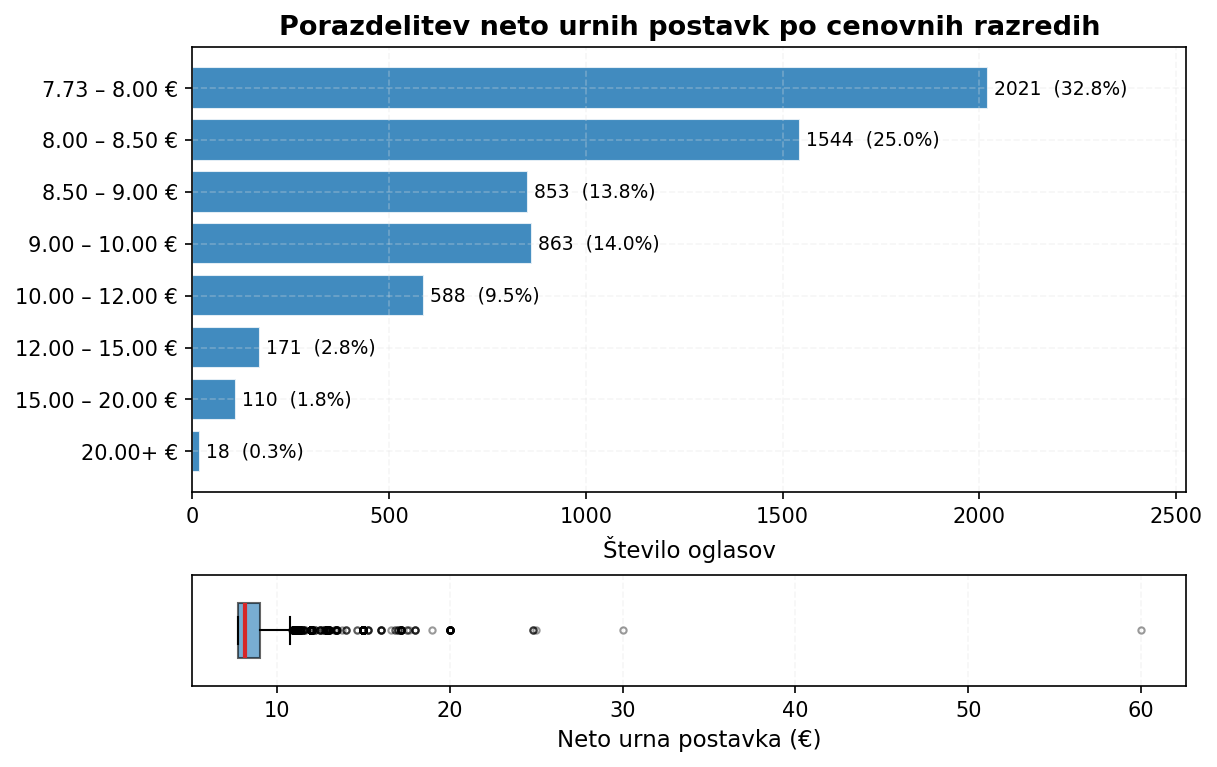

In [4]:
# Filtriramo samo oglase z urnim plačilom
hourly = data[data["normalized_payment_type"] == "HOURLY"].copy()
rates = hourly["hourly_rate_neto"].dropna()
MIN_WAGE = 7.73  # minimalna študentska urna postavka (neto)

# Opisna statistika
stats = rates.describe().to_frame("Neto urna postavka (€)")
stats.index = ["Število oglasov", "Povprečje", "Std. odklon", "Min", "25%", "Mediana (50%)", "75%", "Max"]
display(stats.style.format("{:.2f}"))

# Frekvenčna tabela po cenovnih razredih (od minimalne plače naprej)
bins = [MIN_WAGE, 8, 8.5, 9, 10, 12, 15, 20, 30]
labels = ["7.73 – 8.00 €", "8.00 – 8.50 €", "8.50 – 9.00 €",
          "9.00 – 10.00 €", "10.00 – 12.00 €", "12.00 – 15.00 €",
          "15.00 – 20.00 €", "20.00+ €"]
razredi = pd.cut(rates, bins=bins, labels=labels, right=False)
freq = razredi.value_counts().sort_index().to_frame("Število oglasov")
freq["Delež"] = freq["Število oglasov"] / freq["Število oglasov"].sum()

# Stolpčni graf razredov + box plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), layout="constrained",
                               gridspec_kw={"height_ratios": [4, 1]})

bars = ax1.barh(labels, freq["Število oglasov"], color=COLORS[0], edgecolor="white", alpha=0.85)
ax1.bar_label(bars, labels=[f"{v}  ({p:.1%})" for v, p in zip(freq["Število oglasov"], freq["Delež"])],
              padding=3, fontsize=9)
ax1.set_xlabel("Število oglasov")
ax1.set_title("Porazdelitev neto urnih postavk po cenovnih razredih")
ax1.set_xlim(right=freq["Število oglasov"].max() * 1.25)
ax1.invert_yaxis()

# Box plot pod stolpčnim grafom
bp = ax2.boxplot(rates, vert=False, widths=0.5, patch_artist=True,
                 boxprops=dict(facecolor=COLORS[0], alpha=0.6),
                 medianprops=dict(color=COLORS[3], linewidth=2),
                 flierprops=dict(marker="o", markersize=3, alpha=0.4))
ax2.set_xlabel("Neto urna postavka (€)")
ax2.set_yticks([])

plt.show()

### Število novih oglasov na dan

Koliko novih oglasov se pojavi na portalu vsak dan? Prvi dan zbiranja izpustimo, ker je scraper takrat pobral vse že obstoječe oglase naenkrat.

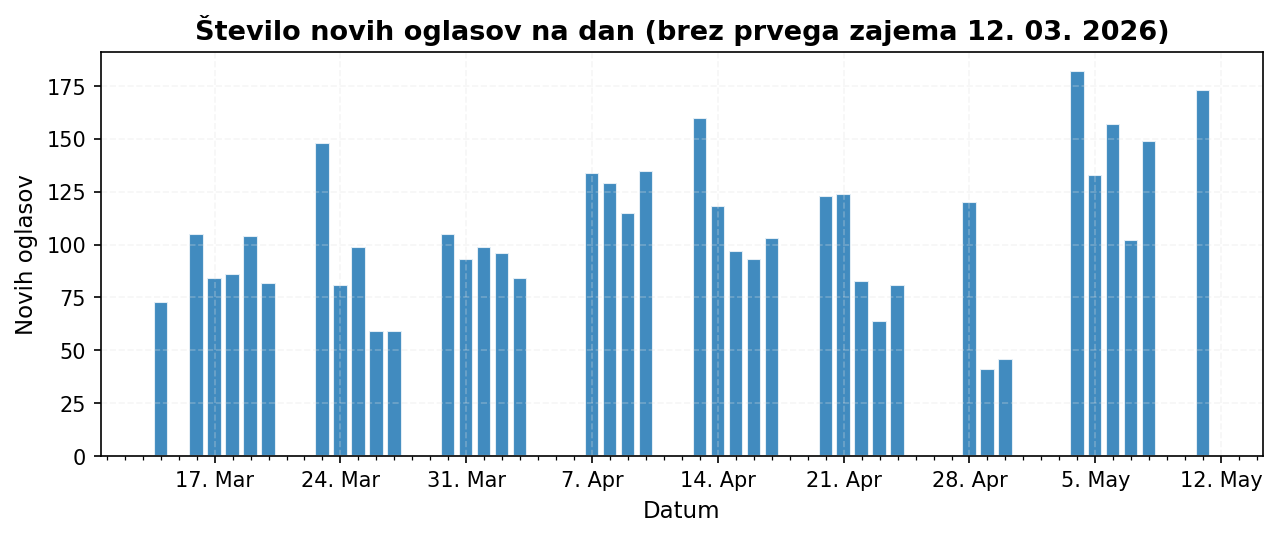

In [5]:
import matplotlib.dates as mdates
import platform

# Število novih oglasov po dnevu (first_seen = kdaj smo oglas prvič videli)
daily_new = data.groupby(data["first_seen"].dt.date).size()

# Izpustimo prvi dan — takrat je scraper pobral vse obstoječe oglase
first_day = daily_new.index.min()
daily_new = daily_new.drop(first_day)

# Pretvorimo datume za matplotlib formatting
dates = pd.to_datetime(daily_new.index)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(dates, daily_new.values, color=COLORS[0], edgecolor="white", alpha=0.85, width=0.8)

# TODO: ob večanju podatkov moramo ustrezno podaljašti inerval prikaza oznake datuma
# Prikažemo vsak 7. dan kot oznako, format "11. mar"
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
fmt = "%#d. %b" if platform.system() == "Windows" else "%-d. %b"  #formatiranje tako deluje pravilno neodvisno od sistema
ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))
ax.xaxis.set_minor_locator(mdates.DayLocator())

ax.set_xlabel("Datum")
ax.set_ylabel("Novih oglasov")
ax.set_title(f"Število novih oglasov na dan (brez prvega zajema {first_day:%d. %m. %Y})")
plt.xticks(rotation=0)
plt.show()

### Oglasi po regijah

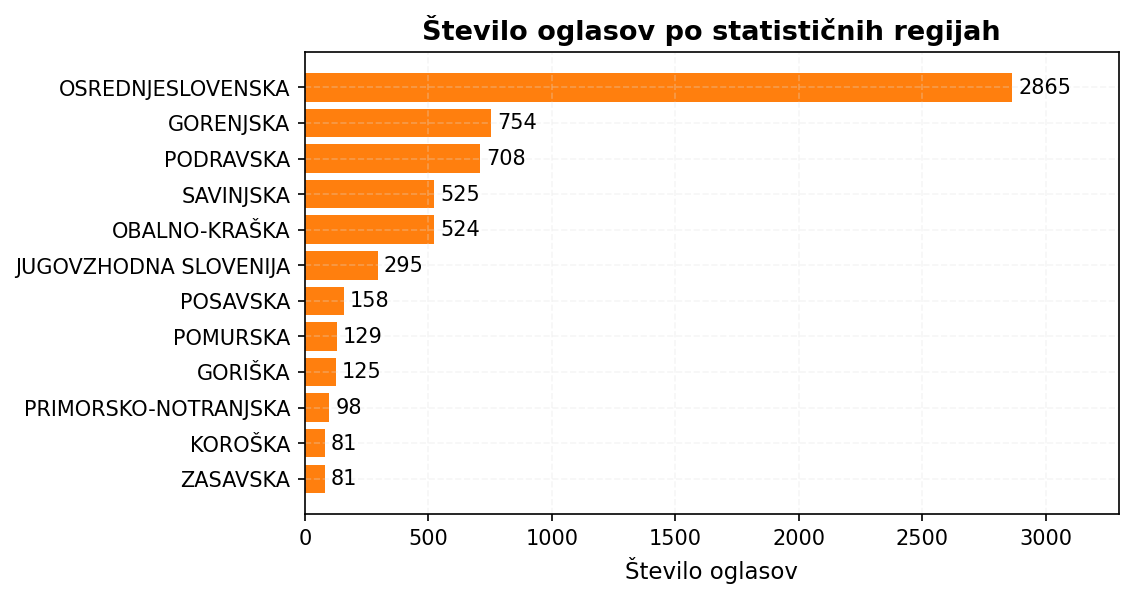

In [6]:
region_counts = data["normalized_region"].value_counts().sort_values()

fig, ax = plt.subplots()
bars = ax.barh(region_counts.index, region_counts.values, color=COLORS[1])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov")
ax.set_title("Število oglasov po statističnih regijah")
ax.set_xlim(right=region_counts.max() * 1.15)
plt.show()

### Tipi plačila

Stolpec `normalized_payment_type` razvršča oglase glede na način izplačila:

| Tip | Slovensko         | Pomen |
|---|-------------------|---|
| `HOURLY` | Urna postavka     | Plačilo na uro dela |
| `NEGOTIABLE` | Po dogovoru       | Plačilo ni vnaprej določeno, dogovor med delodajalcem in študentom |
| `PROJECT` | Projektno plačilo | Fiksno plačilo za celoten projekt ali nalogo |
| `PER_EVENT` | Na dogodek        | Plačilo na posamezen dogodek (npr. promocija, animacija) |
| `PER_TRIP` | Na izlet          | Plačilo na izlet |
| `OTHER` | Drugo             | Netipičen ali nerazpoznan način plačila |

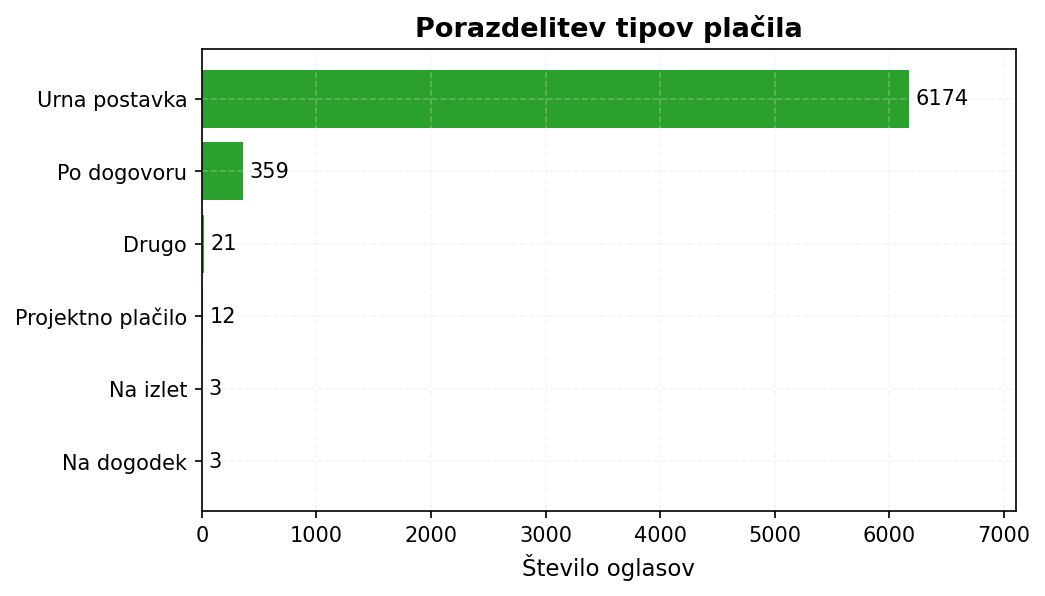

In [7]:
# Mapiramo angleška imena v slovenska
PAYMENT_LABELS = {
    "HOURLY": "Urna postavka",
    "NEGOTIABLE": "Po dogovoru",
    "PROJECT": "Projektno plačilo",
    "PER_EVENT": "Na dogodek",
    "PER_TRIP": "Na izlet",
    "OTHER": "Drugo",
}

payment_counts = data["normalized_payment_type"].map(PAYMENT_LABELS).value_counts().sort_values()

fig, ax = plt.subplots()
bars = ax.barh(payment_counts.index, payment_counts.values, color=COLORS[2])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov")
ax.set_title("Porazdelitev tipov plačila")
ax.set_xlim(right=payment_counts.max() * 1.15)
plt.show()

### Top 10 delodajalcev po številu oglasov

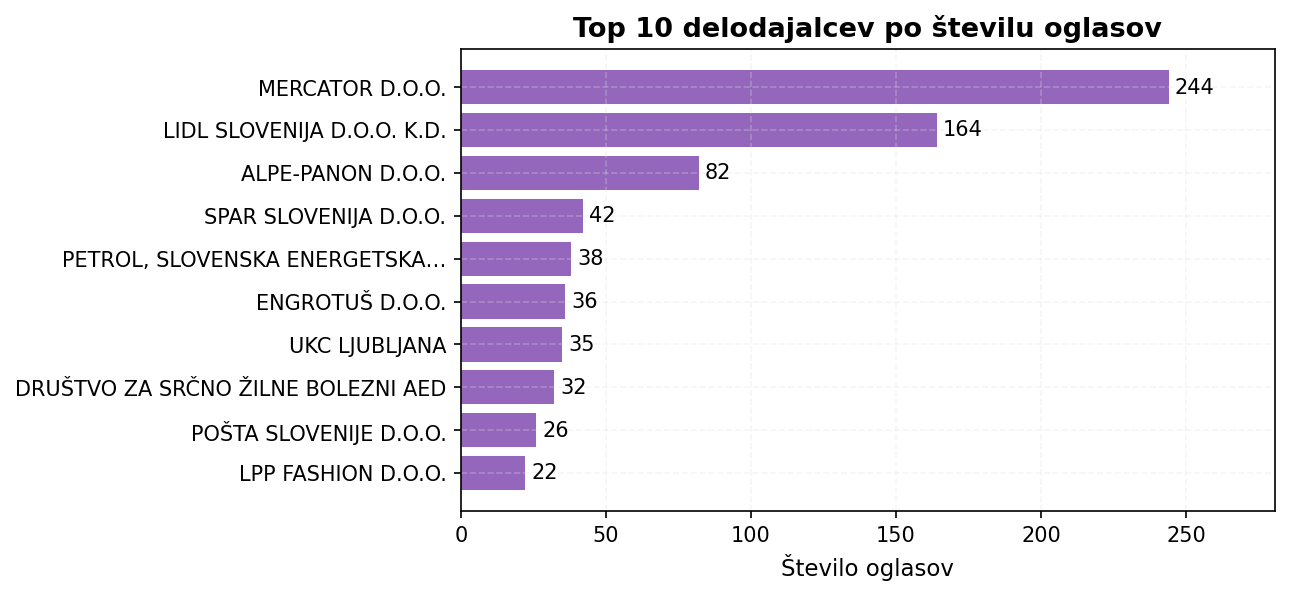

In [8]:
import textwrap

top_companies = data["company"].value_counts().head(10).sort_values()

# Skrajšamo predolga imena (>35 znakov)
short_names = top_companies.index.map(lambda x: textwrap.shorten(x, width=35, placeholder="…"))

fig, ax = plt.subplots()
bars = ax.barh(short_names, top_companies.values, color=COLORS[4])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov")
ax.set_title("Top 10 delodajalcev po številu oglasov")
ax.set_xlim(right=top_companies.max() * 1.15)
plt.show()

### Delovni čas

Kako so oglasi porazdeljeni glede na delovni čas? Stolpec `work_schedule` označuje, kdaj se delo izvaja — dopoldan, popoldan, izmensko, med vikendi ali po dogovoru.

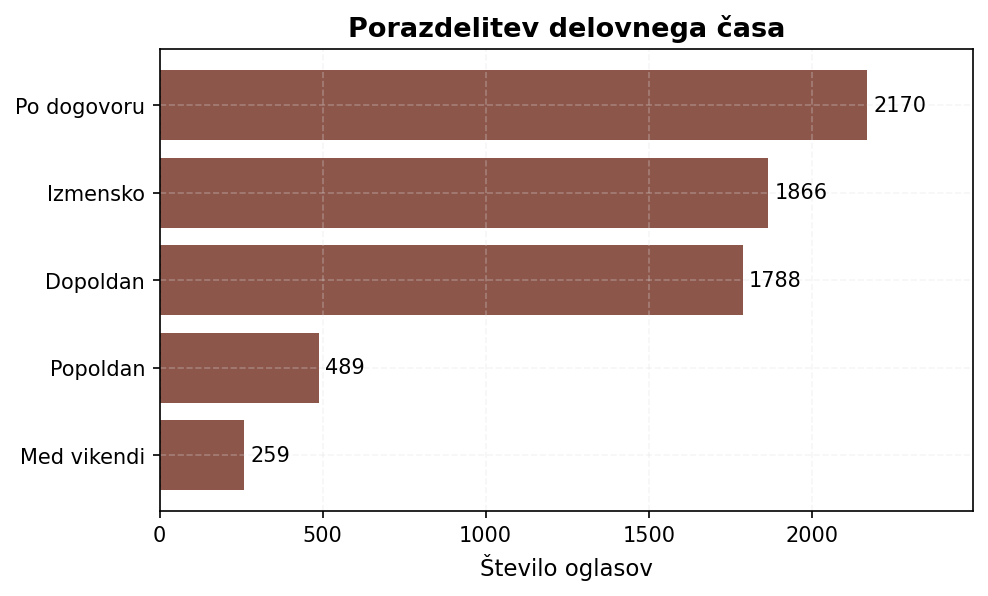

In [9]:
# Porazdelitev delovnega časa
SCHEDULE_LABELS = {
    "PO DOGOVORU": "Po dogovoru",
    "DOPOLDAN": "Dopoldan",
    "POPOLDAN": "Popoldan",
    "IZMENSKO": "Izmensko",
    "MED VIKENDI": "Med vikendi",
}

schedule_counts = data["work_schedule"].map(SCHEDULE_LABELS).value_counts().sort_values()

fig, ax = plt.subplots()
bars = ax.barh(schedule_counts.index, schedule_counts.values, color=COLORS[5])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov")
ax.set_title("Porazdelitev delovnega časa")
ax.set_xlim(right=schedule_counts.max() * 1.15)
plt.show()

### Število prostih mest

Vsak oglas ima lahko podatek o številu prostih mest (`open_positions`). To pove, koliko študentov delodajalec dejansko išče — en oglas lahko pomeni povpraševanje po več delavcih.

In [10]:
# Število prostih mest — koliko študentov dejansko iščejo
positions = data["open_positions"].dropna()

povzetek_mest = pd.DataFrame({
    "Metrika": [
        "Oglasov s podatkom o prostih mestih",
        "Skupno prostih mest",
        "Povprečje na oglas",
        "Mediana na oglas",
        "Največ prostih mest v enem oglasu",
    ],
    "Vrednost": [
        f"{len(positions):,.0f} od {len(data):,.0f} ({len(positions) / len(data) * 100:.0f}%)",
        f"{positions.sum():,.0f}",
        f"{positions.mean():.1f}",
        f"{positions.median():.0f}",
        f"{positions.max():.0f}",
    ],
})
display(povzetek_mest.style.hide(axis="index").set_properties(**{"text-align": "left"}))

# Top 10 oglasov z največ prostimi mesti
top_positions = (
    data.dropna(subset=["open_positions"])
    .nlargest(10, "open_positions")
    [["title", "company", "normalized_city", "open_positions"]]
    .rename(columns={
        "title": "Naslov", "company": "Delodajalec",
        "normalized_city": "Mesto", "open_positions": "Prostih mest",
    })
)
top_positions["Naslov"] = top_positions["Naslov"].apply(
    lambda x: textwrap.shorten(x, 50) if isinstance(x, str) else x)
top_positions["Delodajalec"] = top_positions["Delodajalec"].apply(
    lambda x: textwrap.shorten(x, 35) if isinstance(x, str) else x)

display(Markdown("#### Top 10 oglasov z največ prostimi mesti"))
display(top_positions.style.hide(axis="index").format({"Prostih mest": "{:.0f}"}, na_rep="Ni podatka"))

Metrika,Vrednost
Oglasov s podatkom o prostih mestih,"3,076 od 6,572 (47%)"
Skupno prostih mest,"10,761"
Povprečje na oglas,3.5
Mediana na oglas,2
Največ prostih mest v enem oglasu,50


#### Top 10 oglasov z največ prostimi mesti

Naslov,Delodajalec,Mesto,Prostih mest
DELO V PROIZVODNJI,NOVEM CAR INTERIOR DESIGN D.O.O.,ŽALEC,50
RAZISKOVALNO DELO,PEDAGOŠKI INŠTITUT,Ni podatka,40
HOSTES/A,"ZAVOD BIG, SO.P.",PORTOROŽ/PORTOROSE,40
HOSTES/A,"ZAVOD BIG, SO.P.",PORTOROŽ/PORTOROSE,40
STATIST,"CUT PRODUCTION, TV [...]",LJUBLJANA,30
STATIST,"CUT PRODUCTION, TV [...]",LJUBLJANA,30
DELO V KUHINJI,ALPE-PANON D.O.O.,PTUJ,25
DELO S STRANKAMI,ALPE-PANON D.O.O.,PTUJ,25
DELO S STRANKAMI,ALPE-PANON D.O.O.,PTUJ,25
STREŽBA,VANUM'S D.O.O.,ZREČE,20


### Top 10 mest po številu oglasov

Podrobnejši pogled na lokacijo oglasov — namesto statističnih regij pogledamo posamezna mesta (`normalized_city`).

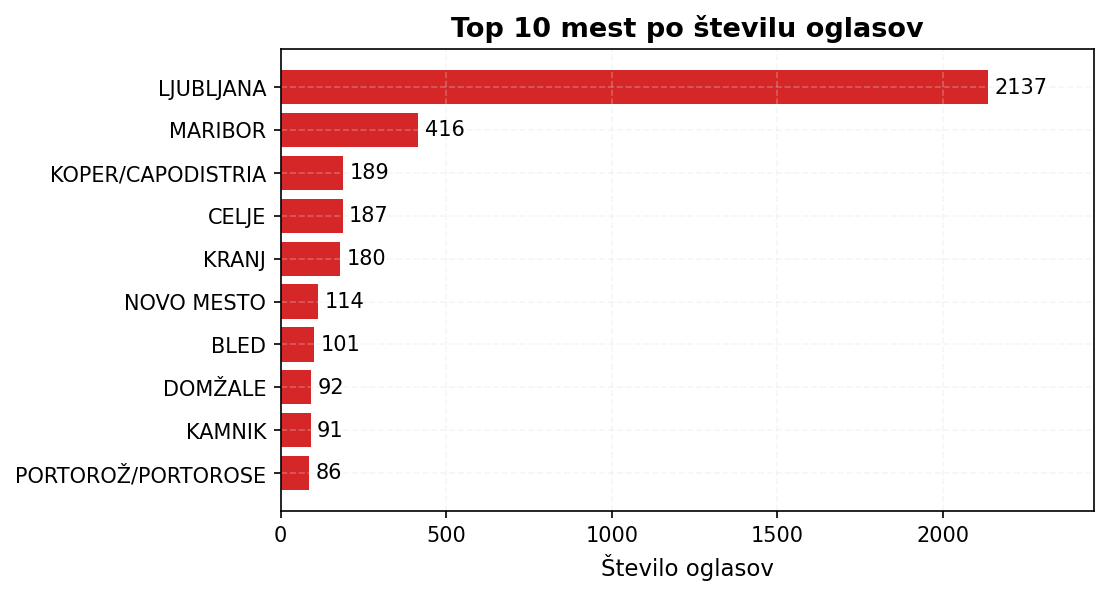

In [11]:
# Top 10 mest po številu oglasov
city_counts = data["normalized_city"].value_counts().head(10).sort_values()

fig, ax = plt.subplots()
bars = ax.barh(city_counts.index, city_counts.values, color=COLORS[3])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov")
ax.set_title("Top 10 mest po številu oglasov")
ax.set_xlim(right=city_counts.max() * 1.15)
plt.show()

---

# Vprašanja

Vsako vprašanje sledi enaki strukturi: **naslov**, **opis**, **analiza**, **vizualizacija** in **ugotovitve**.

## Template za vprašanja

Vsako vprašanje v razdelku **Vprašanja** mora slediti spodnji strukturi:

```
## Vprašanje [N]: [Kratek, jasen naslov]

### Opis
Kaj točno raziskujemo? Zakaj je to vprašanje relevantno? Katere stolpce/podatke
uporabljamo in kakšna je hipoteza, če jo imamo?

### Analiza
[code celica — priprava podatkov, izračuni, tabele]

### Vizualizacija
[code celica — grafi]

### Ugotovitve
- Kaj smo ugotovili?
- Ali se hipoteza potrdi ali ne?
- Kakšne so omejitve analize?
```

## Vprašanje 1: Popularnost programskih (in ostalih) jezikov v opisih oglasov

### Opis

Zanima nas, kateri programski (in ostali) jeziki se najpogosteje pojavljajo v besedilnih opisih študentskih oglasov. S preprosto regex analizo polja `description` iščemo omembe 10 popularnih jezikov (Python, JavaScript, Java, C++, C#, PHP, SQL, TypeScript, HTML, CSS). Rezultat je groba ocena povpraševanja po posameznih jezikih na trgu študentskega dela.

**Omejitev:** Analiza šteje le eksplicitne omembe — oglas za "spletno programiranje" brez navedbe jezika ne bo zajet.

### Analiza

In [12]:
# Regex vzorci za 10 popularnih jezikov
# \b = word boundary, (?!\w) = ne sme slediti črka/številka
# C# in C++ potrebujeta (?!\w) namesto \b ker # in + niso word characters
# [aeiou]? na koncu ujame slovenske sklone (Pythona, Javo, ...)
# Kratice (HTML, CSS, ...) dobijo (?:j?[aeiou])? ker se sklanjajo z j: HTMLja, CSSju
# SQL ujame tudi MySQL, PostgreSQL in MariaDB — vse štejemo pod "SQL"
# JavaScript ujame tudi Node.js / NodeJS — isti jezik, drug runtime
languages = {
    "Python": r"\bPython[aeiou]?\b",
    "JavaScript": r"\bJavaScript[aeiou]?\b|\bNode(?:\.?js|JS)\b",
    "PHP": r"\bPHP(?:j?[aeiou])?\b",
    "SQL": r"\b(?:My|Postgre)?SQL(?:j?[aeiou])?\b|\bMariaDB\b",
    "Java": r"\bJav[aeiou]\b(?!Script)",  # Java/Javo/Jave/Javi — vedno ima samoglasnik
    "C#": r"\bC#(?![a-zA-Z0-9])",  # \b ne deluje za # ker ni word char
    "C++": r"\bC\+\+(?![a-zA-Z0-9])",  # isto za +
    "TypeScript": r"\bTypeScript[aeiou]?\b",
    "HTML": r"\bHTML(?:j?[aeiou])?\b",
    "CSS": r"\bCSS(?:j?[aeiou])?\b",
}

# Preštejemo v koliko oglasih se pojavi vsak jezik (case-insensitive)
desc = data["description"].fillna("")
counts = {
    lang: desc.str.contains(pat, case=False, regex=True).sum()
    for lang, pat in languages.items()
}

# Rezultat kot DataFrame, sortirano naraščajoče za barh graf
lang_df = (
    pd.DataFrame.from_dict(counts, orient="index", columns=["count"])
    .sort_values("count", ascending=True)
)
lang_df = lang_df[lang_df["count"] > 0]  # prikažemo samo jezike ki se dejansko pojavljajo

lang_df

,count
PHP,2
TypeScript,3
CSS,5
HTML,7
C#,8
C++,8
SQL,10
JavaScript,11
Python,19
Java,35


In [13]:
# Koliko oglasov omenja vsaj en programski jezik?
combined_pattern = "|".join(languages.values())
total_with_lang = desc.str.contains(combined_pattern, case=False, regex=True).sum()

povzetek = pd.DataFrame({
    "Metrika": [
        "Oglasov z omembo vsaj enega jezika",
        "Delež vseh oglasov",
        "Najbolj iskan jezik",
    ],
    "Vrednost": [
        f"{total_with_lang} od {len(data)}",
        f"{total_with_lang / len(data) * 100:.1f}%",
        f"{lang_df.index[-1]} ({lang_df['count'].iloc[-1]} oglasov)",
    ],
})
display(povzetek.style.hide(axis="index").set_properties(**{"text-align": "left"}))

Metrika,Vrednost
Oglasov z omembo vsaj enega jezika,64 od 6572
Delež vseh oglasov,1.0%
Najbolj iskan jezik,Java (35 oglasov)


### Vizualizacija

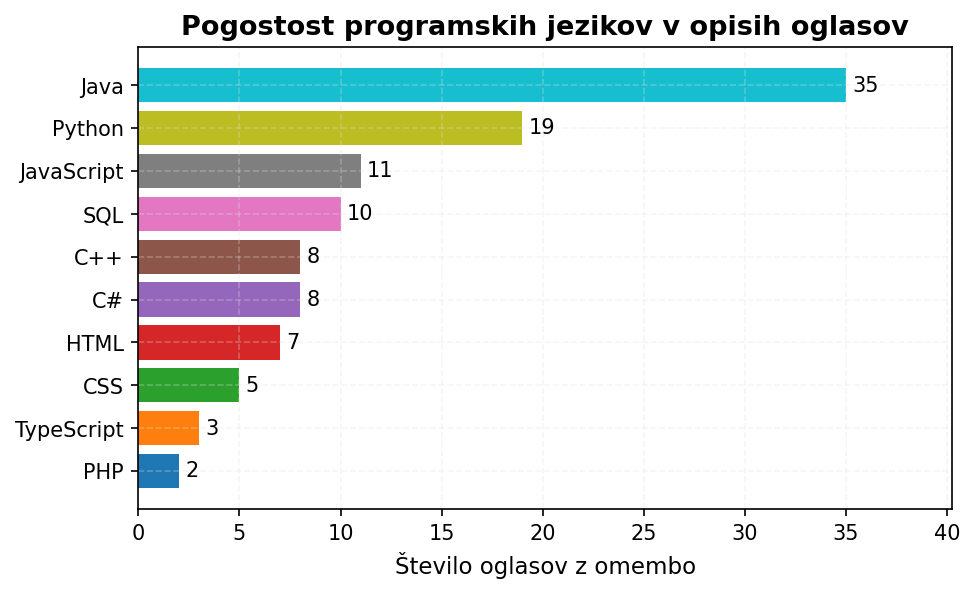

In [14]:
# Horizontalni stolpčni graf — vsak jezik svoja barva za boljšo ločljivost
fig, ax = plt.subplots()
bars = ax.barh(lang_df.index, lang_df["count"], color=COLORS[: len(lang_df)])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov z omembo")
ax.set_title("Pogostost programskih jezikov v opisih oglasov")
ax.set_xlim(right=lang_df["count"].max() * 1.15)
plt.show()

### Ugotovitve

- Kateri jezik prevladuje in zakaj je to pričakovano/presenetljivo?
- Kolikšen delež oglasov sploh omenja programski jezik?

## Vprašanje 2: Ali delodajalci dvigujejo plače, ko oglasa ne morejo zapolniti?

### Opis

Datoteka `changes.csv` beleži vsako spremembo polja na obstoječem oglasu. Če delodajalec po objavi dvigne urno postavko (`hourly_rate_neto`), je to signal, da prvotna ponudba ni pritegnila dovolj kandidatov.

Analiziramo:
- Koliko oglasov je doživelo dvig plače in koliko znižanje?
- Po koliko dneh od objave se tipično zgodi dvig?
- Za koliko se plača dvigne — minimalen popravek ali občuten skok?

**Hipoteza:** Večina sprememb bo dvigov (ne znižanj), do katerih pride v prvih dneh po objavi.

### Analiza

In [15]:
# Iz changes.csv izvlečemo samo spremembe urne postavke
rate_changes = changes[changes["field"] == "hourly_rate_neto"].copy()

# Pretvorimo staro in novo vrednost v številke
rate_changes["old_value"] = pd.to_numeric(rate_changes["old_value"], errors="coerce")
rate_changes["new_value"] = pd.to_numeric(rate_changes["new_value"], errors="coerce")
rate_changes = rate_changes.dropna(subset=["old_value", "new_value"])

# Izračunamo razliko (pozitivna = dvig, negativna = znižanje)
rate_changes["diff"] = rate_changes["new_value"] - rate_changes["old_value"]

# Koliko dni po prvi objavi oglasa je prišlo do spremembe
rate_changes = rate_changes.merge(
    data[["id", "first_seen"]],
    left_on="listing_id", right_on="id", how="left"
)
rate_changes["days_after_post"] = (rate_changes["changed_at"] - rate_changes["first_seen"]).dt.days

# Ločimo dvige in znižanja
raises = rate_changes[rate_changes["diff"] > 0]
cuts = rate_changes[rate_changes["diff"] < 0]

# Povzetek v tabeli
povzetek = pd.DataFrame({
    "Metrika": [
        "Sprememb urne postavke skupaj",
        "Dvigov plače",
        "Znižanj plače",
        "Povprečen dvig (€)",
        "Mediana dni do dviga",
    ],
    "Vrednost": [
        f"{len(rate_changes)}",
        f"{len(raises)} ({len(raises) / len(rate_changes) * 100:.0f}%)" if len(rate_changes) > 0 else "0",
        f"{len(cuts)} ({len(cuts) / len(rate_changes) * 100:.0f}%)" if len(rate_changes) > 0 else "0",
        f"{raises['diff'].mean():.2f} €" if len(raises) > 0 else "—",
        f"{raises['days_after_post'].median():.0f} dni" if len(raises) > 0 else "—",
    ],
})
display(povzetek.style.hide(axis="index").set_properties(**{"text-align": "left"}).format(na_rep="Ni podatka"))

Metrika,Vrednost
Sprememb urne postavke skupaj,230
Dvigov plače,229 (100%)
Znižanj plače,1 (0%)
Povprečen dvig (€),0.84 €
Mediana dni do dviga,25 dni


### Vizualizacija

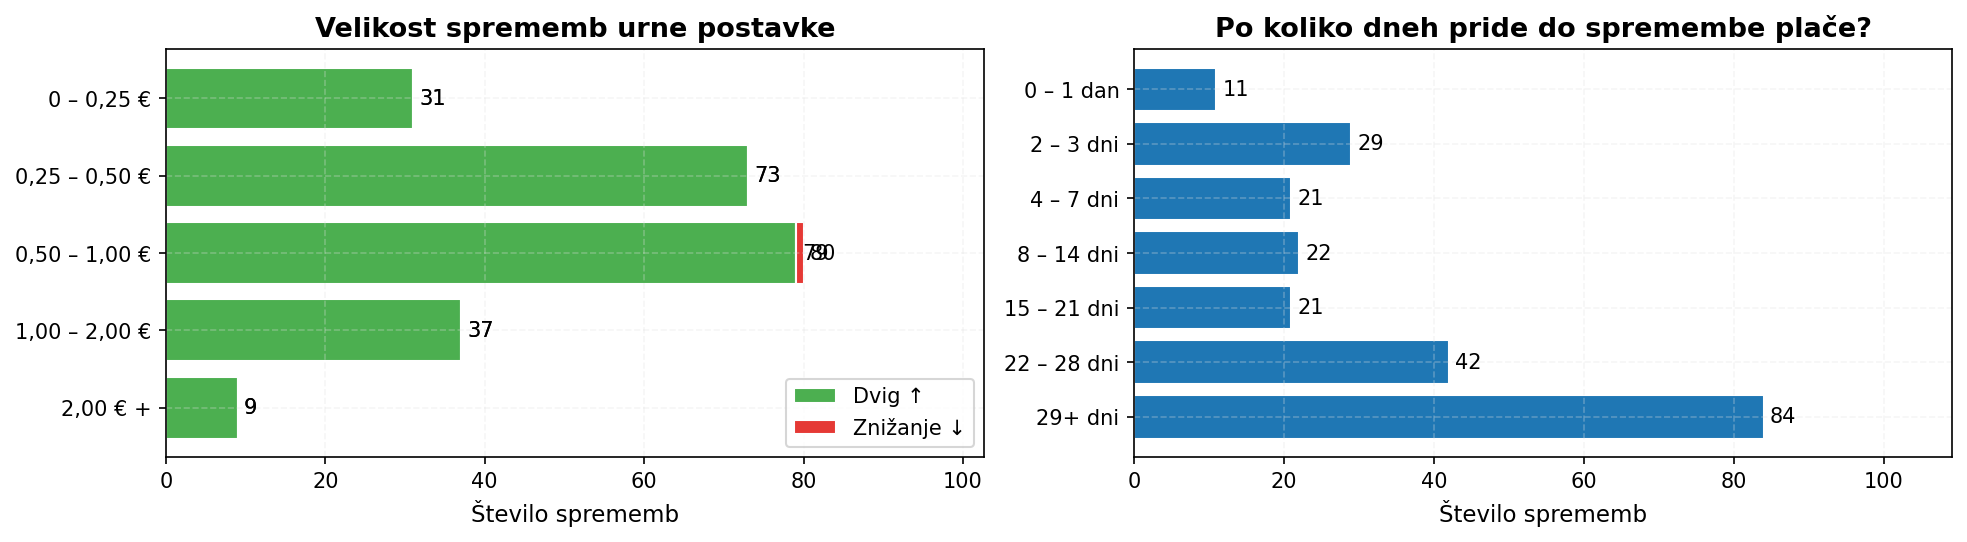

#### Top 10 največjih dvigov

Naslov,Delodajalec,Prej (€),Potem (€),Dvig (€),Dni po objavi
TRŽENJE,7EVEN D.O.O.,12.91,20.00,+7.09,54
ČIŠČENJE,"ARTHA 9, INOVATIVNE REŠITVE, D.O.O.",12.00,18.00,+6.00,15
ČIŠČENJE,"ARTHA 9, INOVATIVNE REŠITVE, D.O.O.",12.00,18.00,+6.00,15
DELO NA BENCINSKEM SERVISU,POSREDNIŠTVO PRI PRODAJI UROŠ [...],10.00,13.00,+3.00,24
DELO S STRANKAMI,"GLOBAL FAST FOOD S, D.O.O.",8.17,10.76,+2.59,3
DELO NA TERENU,"ENERGETIKA LJUBLJANA, D.O.O.",7.74,10.33,+2.59,10
ČIŠČENJE,"KRISTIJANA DJOKIĆ, STORITVE [...]",7.74,10.00,+2.26,5
BLAGAJNIK,LAGARDERE TRAVEL RETAIL [...],7.74,9.90,+2.16,15
MASER/KA,"FREJA, D.O.O.",10.76,12.91,+2.15,43
STREŽBA,"POSREDNIŠTVO PRI PRODAJI, [...]",10.00,12.00,+2.00,6


In [16]:
# --- Graf 1: Velikost sprememb urne postavke (intervali) ---
bins_size = [0, 0.25, 0.50, 1.00, 2.00, float("inf")]
labels_size = ["0 – 0,25 €", "0,25 – 0,50 €", "0,50 – 1,00 €", "1,00 – 2,00 €", "2,00 € +"]

# --- Graf 2: Po koliko dneh pride do spremembe ---
bins_days = [-1, 1, 3, 7, 14, 21, 28, float("inf")]
labels_days = [
    "0 – 1 dan",
    "2 – 3 dni",
    "4 – 7 dni",
    "8 – 14 dni",
    "15 – 21 dni",
    "22 – 28 dni",
    "29+ dni"
]

if len(rate_changes) > 0:
    # Razdelimo spremembe v intervale glede na absolutno vrednost
    rate_changes["abs_diff"] = rate_changes["diff"].abs()
    rate_changes["interval_size"] = pd.cut(rate_changes["abs_diff"], bins=bins_size, labels=labels_size, right=True)
    rate_changes["interval_days"] = pd.cut(rate_changes["days_after_post"], bins=bins_days, labels=labels_days,
                                           right=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5), layout="constrained")

    # --- Levi graf: velikost sprememb ---
    raises_binned = rate_changes[rate_changes["diff"] > 0].groupby("interval_size", observed=False).size()
    cuts_binned = rate_changes[rate_changes["diff"] < 0].groupby("interval_size", observed=False).size()

    bars_r = ax1.barh(labels_size, raises_binned.values, color="#4CAF50", edgecolor="white", label="Dvig ↑")
    ax1.bar_label(bars_r, padding=3, fontsize=10)

    if cuts_binned.sum() > 0:
        bars_c = ax1.barh(labels_size, cuts_binned.values, left=raises_binned.values,
                          color="#E53935", edgecolor="white", label="Znižanje ↓")
        ax1.bar_label(bars_c, padding=3, fontsize=10)
        ax1.legend(loc="lower right")

    ax1.set_xlabel("Število sprememb")
    ax1.set_title("Velikost sprememb urne postavke")
    ax1.set_xlim(right=max(raises_binned.max(), 1) * 1.3)
    ax1.invert_yaxis()

    # --- Desni graf: dni do spremembe ---
    days_binned = rate_changes.groupby("interval_days", observed=False).size()

    bars_d = ax2.barh(labels_days, days_binned.values, color=COLORS[0], edgecolor="white")
    ax2.bar_label(bars_d, padding=3, fontsize=10)
    ax2.set_xlabel("Število sprememb")
    ax2.set_title("Po koliko dneh pride do spremembe plače?")
    ax2.set_xlim(right=max(days_binned.max(), 1) * 1.3)
    ax2.invert_yaxis()

    plt.show()

    # --- Tabela top 10 največjih dvigov ---
    if len(raises) > 0:
        import textwrap

        primeri = (
            raises.merge(data[["id", "title", "company"]], left_on="listing_id", right_on="id", how="left")
            .sort_values("diff", ascending=False)
            [["title", "company", "old_value", "new_value", "diff", "days_after_post"]]
            .head(10)
            .rename(columns={
                "title": "Naslov", "company": "Delodajalec",
                "old_value": "Prej (€)", "new_value": "Potem (€)",
                "diff": "Dvig (€)", "days_after_post": "Dni po objavi",
            })
        )
        primeri["Naslov"] = primeri["Naslov"].apply(lambda x: textwrap.shorten(x, 50) if isinstance(x, str) else x)
        primeri["Delodajalec"] = primeri["Delodajalec"].apply(
            lambda x: textwrap.shorten(x, 35) if isinstance(x, str) else x)
        display(Markdown("#### Top 10 največjih dvigov"))
        display(primeri.style.hide(axis="index").format(
            {"Prej (€)": "{:.2f}", "Potem (€)": "{:.2f}", "Dvig (€)": "+{:.2f}", "Dni po objavi": "{:.0f}"},
            na_rep="Ni podatka"))
else:
    display(Markdown("*V podatkih ni sprememb urne postavke.*"))

### Ugotovitve

- Koliko delodajalcev je dvignilo plačo in ali je to pogost pojav?
- Po koliko dneh se tipično zgodi dvig — je to znak "obupa"?
- Kakšna je povprečna velikost dviga?

## Vprašanje 3: Kje so študentska dela najbolje plačana?

### Opis

Primerjamo mediano neto urne postavke po 12 statističnih regijah Slovenije. Uporabljamo samo oglase s tipom plačila `HOURLY` in znano regijo (`normalized_region`). Za vsako regijo izračunamo mediano, povprečje in število oglasov.

Zanima nas:
- Ali obstaja geografska plačna vrzel med regijami?
- Koliko bolje je plačano delo v Ljubljani / na Obali v primerjavi s preostalo Slovenijo?
- Ali imajo regije z malo oglasi zanesljive ocene?

**Vizualizacija:** Regije pod skupno mediano so obarvane rdeče, nad njo zeleno.

### Analiza

In [17]:
# Filtriramo na oglase z urnim plačilom, znano regijo in urno postavko
hourly_regional = data[
    (data["normalized_payment_type"] == "HOURLY") &
    (data["normalized_region"].notna()) &
    (data["hourly_rate_neto"].notna())
    ].copy()

# Mediana, povprečje in število oglasov po regiji
region_pay = (
    hourly_regional.groupby("normalized_region")["hourly_rate_neto"]
    .agg(["median", "mean", "count"])
    .rename(columns={"median": "Mediana (€)", "mean": "Povprečje (€)", "count": "Št. oglasov"})
    .sort_values("Mediana (€)")
)

# Skupna mediana za primerjavo (čez vse regije)
overall_median = hourly_regional["hourly_rate_neto"].median()
region_pay["Razlika od mediane"] = region_pay["Mediana (€)"] - overall_median

display(Markdown(f"Skupna mediana neto urne postavke: **{overall_median:.2f} €**"))
display(region_pay.style.format({
    "Mediana (€)": "{:.2f}",
    "Povprečje (€)": "{:.2f}",
    "Št. oglasov": "{:.0f}",
    "Razlika od mediane": "{:+.2f}",
}, na_rep="Ni podatka"))

Skupna mediana neto urne postavke: **8.00 €**

,Mediana (€),Povprečje (€),Št. oglasov,Razlika od mediane
normalized_region,,,,
ZASAVSKA,7.81,8.11,76,-0.19
JUGOVZHODNA SLOVENIJA,8.00,8.46,278,+0.00
PODRAVSKA,8.00,8.41,659,+0.00
POMURSKA,8.00,8.42,117,+0.00
SAVINJSKA,8.00,8.60,500,+0.00
PRIMORSKO-NOTRANJSKA,8.00,8.43,97,+0.00
POSAVSKA,8.00,8.40,152,+0.00
KOROŠKA,8.01,8.55,76,+0.01
OBALNO-KRAŠKA,8.17,8.58,492,+0.17


### Vizualizacija

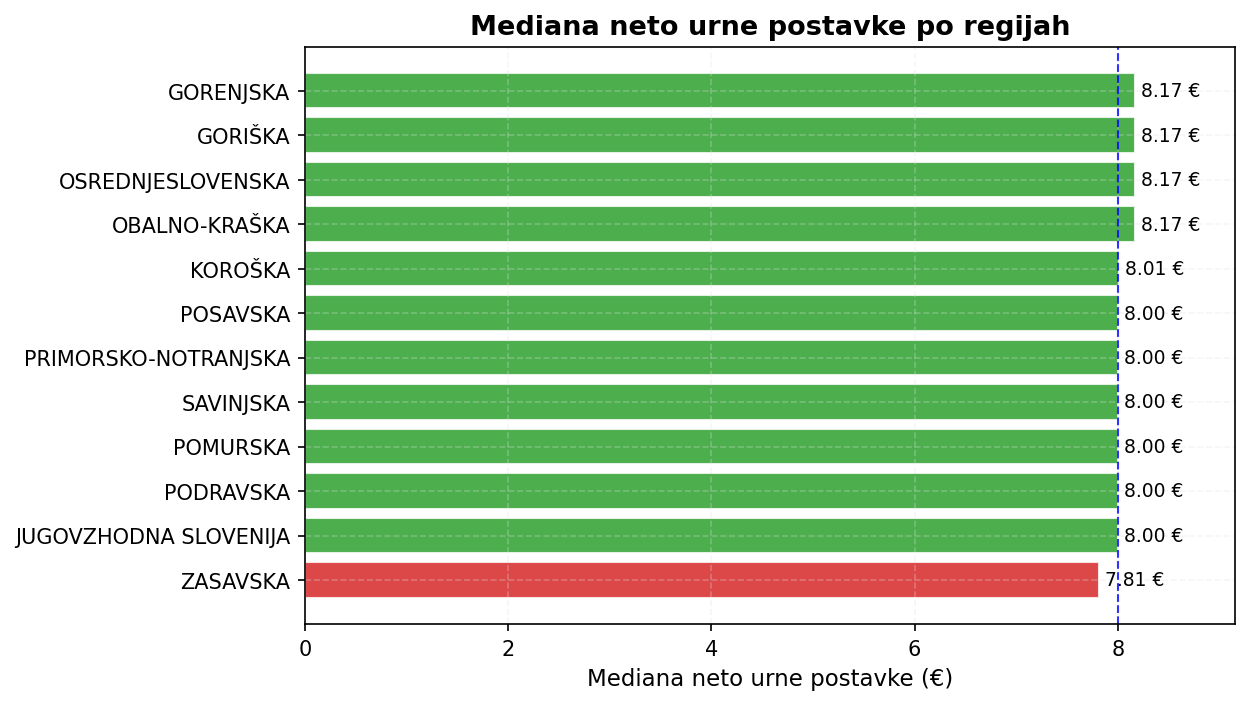

In [18]:
# Horizontalni stolpčni graf median po regijah
# Rdeče = pod skupno mediano, zeleno = nad
fig, ax = plt.subplots(figsize=(8, 5))

colors_region = [COLORS[3] if v < overall_median else COLORS[2] for v in region_pay["Mediana (€)"]]
bars = ax.barh(region_pay.index, region_pay["Mediana (€)"], color=colors_region, edgecolor="white", alpha=0.85)
ax.bar_label(bars, labels=[f"{v:.2f} €" for v in region_pay["Mediana (€)"]], padding=3, fontsize=9)

# Črtkana črta za skupno mediano z anotacijo ob spodnjem robu
ax.axvline(overall_median, color="blue", linestyle="--", linewidth=1, alpha=0.8)
#ax.annotate(f"  {overall_median:.2f} €\n  (mediana)",
#            xy=(overall_median, len(region_pay) - 0.5),
#            fontsize=8, fontstyle="italic", va="top")

ax.set_xlabel("Mediana neto urne postavke (€)")
ax.set_title("Mediana neto urne postavke po regijah")
ax.set_xlim(right=region_pay["Mediana (€)"].max() * 1.12)
plt.show()

### Ugotovitve

- Katera regija ima najvišjo mediano in ali je to pričakovano?
- Kako velika je razlika med najbolje in najslabše plačano regijo?
- Ali število oglasov v regiji vpliva na zanesljivost ocene (majhne regije z malo oglasi)?

## Vprašanje 4: Kako se trajanje študentskega dela razlikuje glede na vrsto dela?

### Opis
Raziskujemo, ali se in kako se trajanje študentskega dela razlikuje glede na vrsto dela (pridobimo najpogostejše vrste dela glede na ime npr. pomoč v trgovini, IT, strežba).

Študentom, ki si aktivno iščejo delo, lahko to pove v katerih panogah lahko preko študentskega servisa pričakujejo bolj dolgoročno delo in pri katerih delih je čas trajanja bolj prilagodljiv. 

Zanima nas:
- Ali obstajajo jasni vzorci med vrsto dela in časom trajanja? 
- Katere vrste dela so najbolj dolgotrajne?
- Pri katerih vrstah dela je čas trajanja najbolj prilagodljiv?

Uporabimo bomo atribut `duration` za določanje trajnosti dela, ter atributa `title` in `subtitle` za določanje vrste dela.  


### Analiza


In [19]:
duration = data["duration"].str.upper().fillna("")


def map_duration(d):
    if "DLJE ČASA" in d:
        return "DLJE ČASA"
    elif "PO DOGOVORU" in d:
        return "PO DOGOVORU"
    else:
        return "OSTALO"


titles = (data["title"].fillna("") + " " + data["subtitle"].fillna("")).str.upper()


def categorize(title):
    if "PROGRAMIRANJE" in title or "IT" in title:
        return "IT"
    elif "STREŽBA" in title or "KUHINJI" in title:
        return "GOSTINSTVO"
    elif "TRGOVINI" in title or "PRODAJA" in title or "BLAGAJNIK" in title:
        return "PRODAJA"
    elif "ADMINISTRATIVNA" in title or "ADMINISTRACIJA" in title:
        return "ADMINISTRACIJA"
    elif "PROIZVODNJI" in title or "PROIZVODNJA" in title:
        return "PROIZVODNJA"
    else:
        return "OSTALO"


data["category"] = titles.map(categorize)

data["trajanje"] = duration.map(map_duration)


def make_table(df):
    counts = df["trajanje"].value_counts()
    total = len(df)

    result = pd.DataFrame({
        "stevilo": counts,
        "delež (%)": (counts / total * 100).round(2)
    })

    return result


categories = ["GOSTINSTVO", "PRODAJA", "ADMINISTRACIJA", "PROIZVODNJA", "IT"]
table_data = {}
row_names = ["SPLOŠNO"] + categories
for name in row_names:
    if name == "SPLOŠNO":  #splošno -> vsa dela(da bomo imeli za primerjavo odstopanja pri specifičnih vrstah)
        df = data
    else:
        df = data[data["category"] == name]
    total = len(df)
    counts = df["trajanje"].value_counts().reindex(["DLJE ČASA", "PO DOGOVORU", "OSTALO"], fill_value=0)
    percentages = (counts / total * 100).round(2) if total > 0 else pd.Series([0.0] * 3,
                                                                              index=["DLJE ČASA", "PO DOGOVORU",
                                                                                     "OSTALO"])
    formatted = {
        "Dlje časa": f"{int(counts['DLJE ČASA'])} ({percentages['DLJE ČASA']:.2f}%)".replace(".", ","),
        "Po dogovoru": f"{int(counts['PO DOGOVORU'])} ({percentages['PO DOGOVORU']:.2f}%)".replace(".", ","),
        "Ostalo": f"{int(counts['OSTALO'])} ({percentages['OSTALO']:.2f}%)".replace(".", ","),
        "Skupaj": int(total)
    }
    table_data[name] = formatted

result_table = pd.DataFrame(table_data).T
display(result_table)

,Dlje časa,Po dogovoru,Ostalo,Skupaj
SPLOŠNO,"4329 (65,87%)","1715 (26,10%)","528 (8,03%)",6572
GOSTINSTVO,"1041 (70,10%)","395 (26,60%)","49 (3,30%)",1485
PRODAJA,"564 (60,65%)","331 (35,59%)","35 (3,76%)",930
ADMINISTRACIJA,"248 (81,05%)","51 (16,67%)","7 (2,29%)",306
PROIZVODNJA,"153 (71,50%)","47 (21,96%)","14 (6,54%)",214
IT,"330 (72,37%)","94 (20,61%)","32 (7,02%)",456


### Vizualizacija

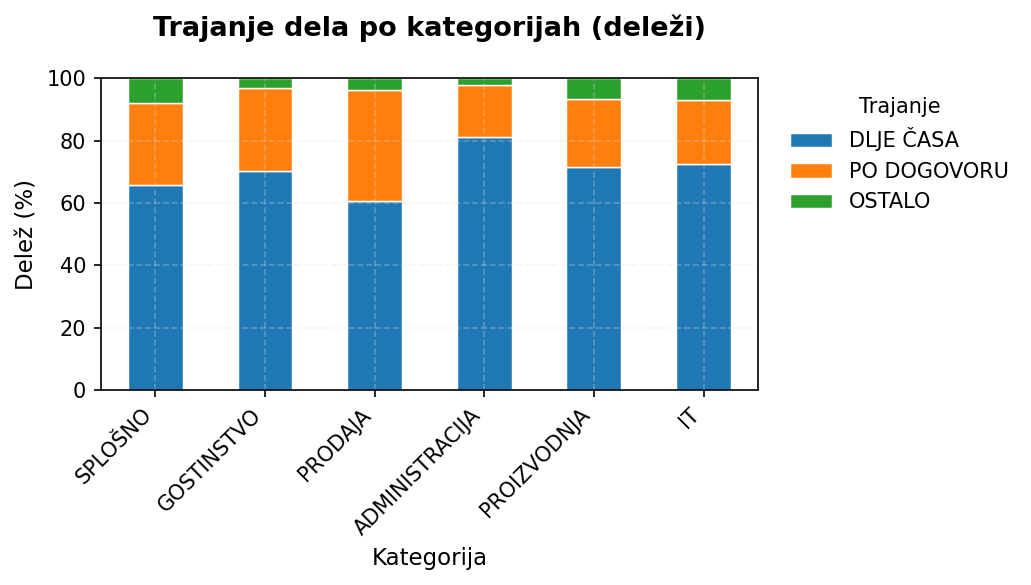

In [20]:
pivot_pct = result_table[["Dlje časa", "Po dogovoru", "Ostalo"]].copy()
#pretvorba deležev v float
pivot_pct = pivot_pct.apply(lambda col: col.astype(str)
                            .str.extract(r'\((.*?)%\)', expand=False)
                            .str.replace(',', '.')
                            .astype(float))

pivot_pct.columns = ["DLJE ČASA", "PO DOGOVORU", "OSTALO"]

category_order = ["SPLOŠNO", "GOSTINSTVO", "PRODAJA", "ADMINISTRACIJA", "PROIZVODNJA", "IT"]
pivot_pct = pivot_pct.reindex(category_order)

plot_data = pivot_pct.dropna(how='all')

ax = plot_data.plot(
    kind="bar",
    stacked=True,
    color=COLORS[:3],
    edgecolor='white',
    linewidth=0.7
)

plt.title("Trajanje dela po kategorijah (deleži)", pad=20)
plt.xlabel("Kategorija")
plt.ylabel("Delež (%)")
plt.ylim(0, 100)

plt.legend(
    title="Trajanje",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Ugotovitve
- Katere vrste dela so najbolj dolgotrajne? 
- Katere vrste del imajo najbolj prilagodljiv čas trajanja? [prodaja]
- Ena od glavnih omejitev je, da sta na študentskem servisu samo dve glavni in dovolj številčni vrsti trajanja dela(dlje časa in po dogovoru), v primeru, da bi jih bilo več bi bila analiza lahko natančnejša   

## Vprašanje 5: Ali določeni dnevi v tednu prinašajo več novih oglasov?

### Opis
Raziskujemo, ali so določeni dnevi v tednu bolj "aktivni" za objavo novih študentskih del. Študentom, ki si aktivno iščejo delo, lahko ta informacija pomaga, da spremljajo portal ob pravih dnevih in se prijavijo med prvimi.

Uporabimo stolpec `first_seen`, tako da iz datuma izluščimo dan v tednu in izračunamo povprečno število novih oglasov za vsak dan. Izpustimo prvi dan zajema, saj je takrat scraper pobral vse obstoječe oglase.

**Hipoteza:** Med tednom (ponedeljek–petek) je več novih oglasov kot ob vikendih.

### Analiza

In [21]:
# Število novih oglasov po dnevu (first_seen = kdaj smo oglas prvič videli)
daily_new_v5 = data.groupby(data["first_seen"].dt.date).size()

# Izpustimo prvi dan — takrat je scraper pobral vse obstoječe oglase
first_day_v5 = daily_new_v5.index.min()
daily_new_v5 = daily_new_v5.drop(first_day_v5)

# 14.3.2026 (sobota) je scraper pobral petkov zajem, ker v petek ni bil pognan.
# Prestavimo te oglase na petek 13.3.2026.
from datetime import date

sat = date(2026, 3, 14)
fri = date(2026, 3, 13)
if sat in daily_new_v5.index:
    daily_new_v5[fri] = daily_new_v5.get(fri, 0) + daily_new_v5[sat]
    daily_new_v5[sat] = 0

# Ustvarimo polni date range (vključno z dnevi brez novih oglasov)
full_range = pd.date_range(daily_new_v5.index.min(), daily_new_v5.index.max(), freq="D")
daily_new_v5 = daily_new_v5.reindex(full_range.date, fill_value=0)

# Dodamo dan v tednu (0 = ponedeljek, 6 = nedelja)
daily_df = pd.DataFrame({"date": daily_new_v5.index, "count": daily_new_v5.values})
daily_df["weekday"] = pd.to_datetime(daily_df["date"]).dt.dayofweek

# Slovenska imena dni
day_names = ["Ponedeljek", "Torek", "Sreda", "Četrtek", "Petek", "Sobota", "Nedelja"]

# Povprečno število novih oglasov po dnevu v tednu (reindex da so vsi dnevi prisotni)
avg_by_day = daily_df.groupby("weekday")["count"].agg(["mean", "count"]).rename(
    columns={"mean": "Povprečje novih oglasov", "count": "Število dni v vzorcu"}
)
avg_by_day = avg_by_day.reindex(range(7), fill_value=0)
avg_by_day.index = [day_names[i] for i in avg_by_day.index]
avg_by_day["Povprečje novih oglasov"] = avg_by_day["Povprečje novih oglasov"].round(1)

display(avg_by_day)

,Povprečje novih oglasov,Število dni v vzorcu
Ponedeljek,110.7,9
Torek,110.9,8
Sreda,98.9,8
Četrtek,84.9,8
Petek,85.1,9
Sobota,0.0,9
Nedelja,0.0,9


### Vizualizacija

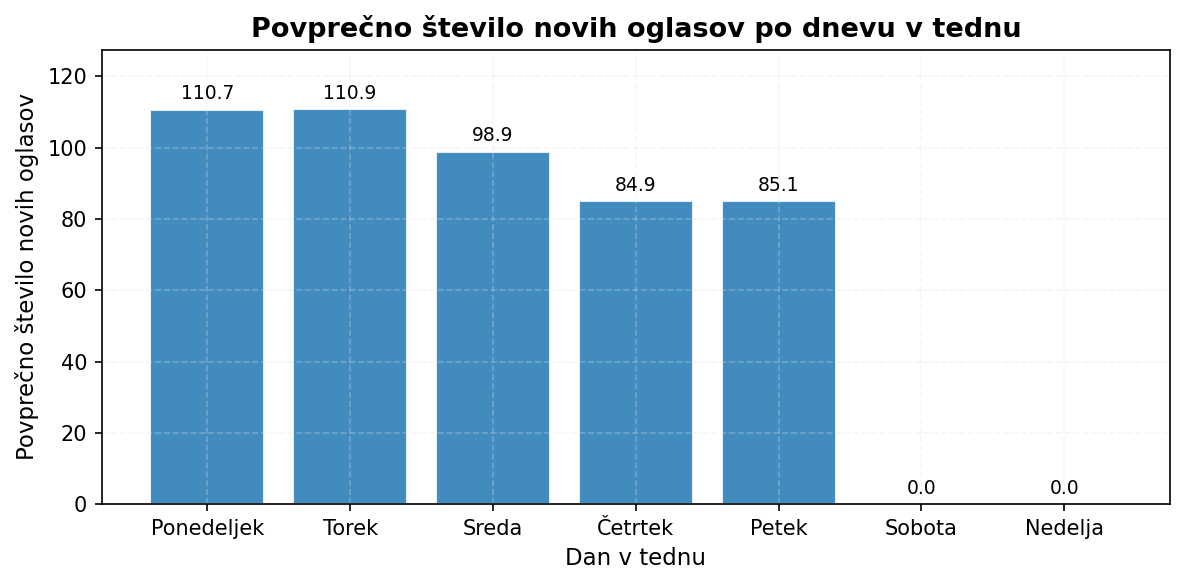

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    avg_by_day.index,
    avg_by_day["Povprečje novih oglasov"],
    color=COLORS[0],
    edgecolor="white",
    alpha=0.85,
)
ax.bar_label(bars, labels=[f"{v:.1f}" for v in avg_by_day["Povprečje novih oglasov"]], padding=3, fontsize=9)

ax.set_xlabel("Dan v tednu")
ax.set_ylabel("Povprečno število novih oglasov")
ax.set_title("Povprečno število novih oglasov po dnevu v tednu")
ax.set_ylim(top=avg_by_day["Povprečje novih oglasov"].max() * 1.15)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Ugotovitve
- Za zapis ugotovitev moramo počakati do vsaj konca aprila, da bomo imeli zadosti rezultatov.
- Pomembno je omeniti, da določimo dan novih oglasov na podlagi `first_seen`. Z eno soboto (14.3.2026) je problem, ker smo pognali scarper v soboto, pobral pa je nove oglase za petek, ker scraper ni bil pognan v petek. Ker imamo sedaj scarper avtomatiziran, ne bo prišlo več do teh težav. Razultat ~~bomo~~ smo mogli malce prirediti, tako da ~~bomo~~ smo za to eno soboto dodali razlutate v petek.
---
- Kateri dnevi v tednu imajo največ novih oglasov?
- Ali se hipoteza potrdi, da je med tednom (pon–pet) več novih oglasov kot ob vikendih?
- Katere dni bi študentom priporočili, da redno preverjajo portal?
- Omejitev: vzorec zajema relativno kratko obdobje, zato rezultati morda niso popolnoma posplošljivi.

## Vprašanje 6: Ali dela z manj prostimi mesti ponujajo višjo plačo?

### Opis
Raziskujemo, ali obstaja povezava med številom prostih mest (`open_positions`) in povprečno neto urno postavko (`hourly_rate_neto`). Ali dela, ki imajo manj razpoložljivih delovnih mest, plačujejo več — ker so morda bolj specializirana ali zahtevna?

Filtriramo na oglase z urnim tipom plačila (`HOURLY`). Oglase razdelimo v intervale glede na število prostih mest. Kjer stolpec `open_positions` ni izpolnjen, predpostavimo 1 prosto mesto — to je smiselno, saj je najnižja eksplicitna vrednost v podatkih 2.

**Hipoteza:** Dela z manj prostimi mesti ponujajo višjo povprečno plačo.

### Analiza

In [23]:
# Filtriramo na urni tip plačila z znano plačo
df_v6 = data[
    (data["normalized_payment_type"] == "HOURLY")
    & data["hourly_rate_neto"].notna()
    ].copy()

# Kjer open_positions ni izpolnjen, predpostavimo 1 prosto mesto
df_v6["open_positions"] = df_v6["open_positions"].fillna(1)

# Intervali prostih mest
bins = [0, 1, 2, 4, 9, float("inf")]
labels = ["1", "2", "3–4", "5–9", "10+"]
df_v6["interval"] = pd.cut(df_v6["open_positions"], bins=bins, labels=labels, right=True)

# Povprečje, mediana in število oglasov po intervalu
pay_by_positions = df_v6.groupby("interval", observed=False)["hourly_rate_neto"].agg(
    ["mean", "median", "count"]
).rename(columns={"mean": "Povprečje (€)", "median": "Mediana (€)", "count": "Št. oglasov"})
pay_by_positions["Povprečje (€)"] = pay_by_positions["Povprečje (€)"].round(2)
pay_by_positions["Mediana (€)"] = pay_by_positions["Mediana (€)"].round(2)
pay_by_positions.index.name = "Prosta mesta"

display(Markdown(f"**Število vključenih oglasov:** {len(df_v6)}"))
display(pay_by_positions)

**Število vključenih oglasov:** 6170

,Povprečje (€),Mediana (€),Št. oglasov
Prosta mesta,,,
1,8.64,8.00,3314
2,8.67,8.12,1478
3–4,8.67,8.15,883
5–9,9.32,8.17,337
10+,8.97,8.17,158


### Vizualizacija

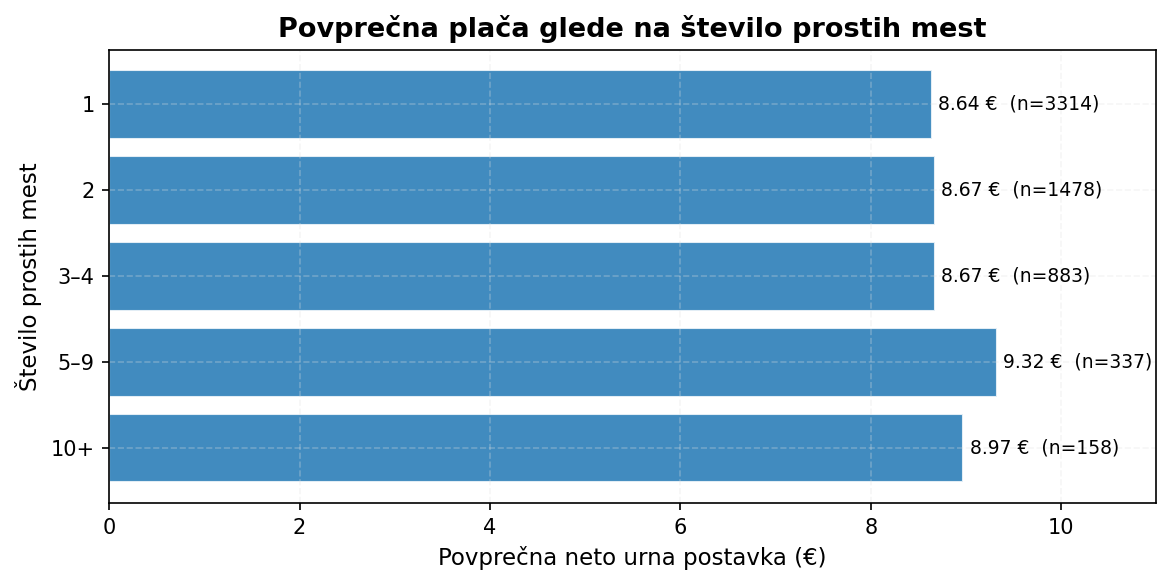

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    pay_by_positions.index,
    pay_by_positions["Povprečje (€)"],
    color=COLORS[0],
    edgecolor="white",
    alpha=0.85,
)
ax.bar_label(
    bars,
    labels=[f"{v:.2f} €  (n={n})" for v, n in zip(pay_by_positions["Povprečje (€)"], pay_by_positions["Št. oglasov"])],
    padding=3,
    fontsize=9,
)

ax.set_ylabel("Število prostih mest")
ax.set_xlabel("Povprečna neto urna postavka (€)")
ax.set_title("Povprečna plača glede na število prostih mest")
ax.set_xlim(right=pay_by_positions["Povprečje (€)"].max() * 1.18)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Ugotovitve
- Ali dela z manj prostimi mesti res ponujajo višjo plačo?
- Kako velika je razlika med intervali?
- Ali je vzorec dovolj velik v vseh intervalih za zanesljive zaključke?
- Predpostavka: oglasi brez izpolnjenega `open_positions` imajo 1 prosto mesto (najnižja eksplicitna vrednost je 2).

## Vprašanje 7: Ali se “hitro zapolnjena” dela razlikujejo po plači?

### Opis
Analiziramo, ali oglasi, ki ostanejo krajši čas aktivni na portalu (razlika med `last_seen` in `first_seen`), ponujajo višje ali nižje plačilo.

Cilj je preveriti, ali se bolje plačana dela hitreje zapolnijo in posledično hitreje izginejo iz sistema.

Omejitev: Uporabljamo samo oglase z urnim plačilom, saj omogočajo primerljivo analizo med oglasi.

### Hipoteza
Oglasi z višjo urno postavko se zapolnijo hitreje (imajo krajše trajanje).

#### TODO (pomembno za interpretacijo)
Ugotovitve je treba posodobiti, ko bo scraper deloval dalj časa.
Trenutno je veliko oglasov še vedno aktivnih (še niso zaključeni), kar pomeni, da je izračun trajanja delno podcenjen.
Zato trenutno ne moremo popolnoma zanesljivo sklepati o “hitrosti zapolnitve”, ampak le o približnem odnosu med plačo in trajanjem oglasa.

### Analiza

In [25]:
# filtriramo samo oglase z urno postavko
hourly_ads = data[data["hourly_rate_neto"].notna()].copy()

# trajanje oglasa v dnevih
hourly_ads["ad_duration_days"] = (
        hourly_ads["last_seen"] - hourly_ads["first_seen"]
).dt.days

# odstrani napačne vrednosti
hourly_ads = hourly_ads[hourly_ads["ad_duration_days"] >= 0]

stats = pd.DataFrame({
    "Metrika": [
        "Število oglasov z urno postavko",
        "Povprečna plača (€)",
        "Povprečno trajanje (št. dni)",
        "Min trajanje oglasa",
        "Max trajanje oglasa"
    ],
    "Vrednost": [
        len(hourly_ads),
        hourly_ads["hourly_rate_neto"].mean().round(2),
        hourly_ads["ad_duration_days"].mean().round(2),
        hourly_ads["ad_duration_days"].min(),
        hourly_ads["ad_duration_days"].max()
    ]
})

correlation = hourly_ads["hourly_rate_neto"].corr(hourly_ads["ad_duration_days"])

#formatiran izpis za lažjo berljivost
display(
    stats.style
    .hide(axis="index")
    .format({"Vrednost": "{:.2f}"}, na_rep="—")
)
display(Markdown(f"""
Pearsonova korelacija med `hourly_rate_neto` in `ad_duration_days` je: {correlation:.3f}**
"""))

Metrika,Vrednost
Število oglasov z urno postavko,6170.00
Povprečna plača (€),8.69
Povprečno trajanje (št. dni),23.92
Min trajanje oglasa,0.00
Max trajanje oglasa,59.00



Pearsonova korelacija med `hourly_rate_neto` in `ad_duration_days` je: -0.024**


### Vizualizacija

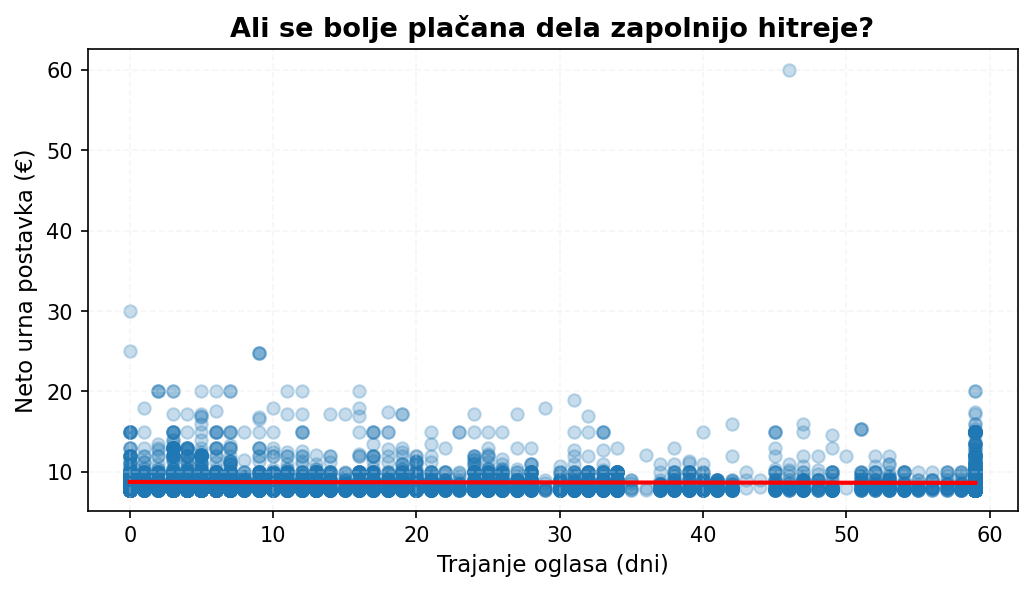

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(
    hourly_ads["ad_duration_days"],
    hourly_ads["hourly_rate_neto"],
    alpha=0.25,
    color=COLORS[0]
)

# trend linija
z = np.polyfit(hourly_ads["ad_duration_days"], hourly_ads["hourly_rate_neto"], 1)
p = np.poly1d(z)

x_line = np.linspace(
    hourly_ads["ad_duration_days"].min(),
    hourly_ads["ad_duration_days"].max(),
    100
)

ax.plot(x_line, p(x_line), color="red", linewidth=2)

ax.set_xlabel("Trajanje oglasa (dni)")
ax.set_ylabel("Neto urna postavka (€)")
ax.set_title("Ali se bolje plačana dela zapolnijo hitreje?")

plt.show()

In [27]:
display(Markdown(f"""
### Ugotovitve

- V podatkih ni opazne povezave med višino urne postavke in trajanjem oglasa.
- Korelacija je približno **{correlation:.3f}**, kar pomeni, da ni opazne linearne povezave med plačo in trajanjem oglasa.
- Trendna linija na grafu je skoraj ravna, kar dodatno potrjuje odsotnost linearnega trenda.

Na podlagi podatkov ne moremo trditi, da višja plača pomeni hitrejšo zapolnitev oglasa.
"""))


### Ugotovitve

- V podatkih ni opazne povezave med višino urne postavke in trajanjem oglasa.
- Korelacija je približno **-0.024**, kar pomeni, da ni opazne linearne povezave med plačo in trajanjem oglasa.
- Trendna linija na grafu je skoraj ravna, kar dodatno potrjuje odsotnost linearnega trenda.

Na podlagi podatkov ne moremo trditi, da višja plača pomeni hitrejšo zapolnitev oglasa.


## Vprašanje 8: Kdo obvladuje trg študentskega dela? Koncentracija oglasov med podjetji

### Opis
Analiziramo, kako so študentski oglasi porazdeljeni med podjetja.

Zanima nas, ali trg študentskega dela obvladuje nekaj velikih delodajalcev ali pa je bolj razpršen med veliko manjših podjetij.

Za analizo uporabimo Pareto princip in porazdelitev oglasov po podjetjih.

#### Opis pareto principa
Pareto princip (80/20 pravilo) pravi, da približno 20 % vzrokov pogosto ustvari 80 % posledic.
V kontekstu naše analize to pomeni, da preverjamo, ali majhno število podjetij ustvari večino oglasov na platformi.

#### Opis long-tail analize
Long-tail analiza opisuje porazdelitev, kjer majhno število enot prispeva velik del aktivnosti, medtem ko velika večina enot prispeva le majhen del.
V našem primeru to pomeni, da majhno število podjetij ustvari velik delež oglasov, medtem ko ima veliko podjetij le enega ali nekaj oglasov.

Cilj je ugotoviti:
- ali majhno število podjetij generira večino oglasov
- kako močna je koncentracija trga
- ali obstaja dolg “rep” manjših delodajalcev

### Hipoteza
Majhno število podjetij generira večino oglasov na platformi (Pareto princip približno velja), medtem ko večina podjetij prispeva le majhen delež oglasov.


### Analiza

In [28]:
# Število oglasov po podjetjih
company_counts = data["company"].value_counts()

total_ads = len(data)

# Koncentracija trga
top_1_share = (company_counts.head(1).sum() / total_ads) * 100
top_5_share = (company_counts.head(5).sum() / total_ads) * 100
top_10_share = (company_counts.head(10).sum() / total_ads) * 100

# Long tail analiza
one_ad_companies = (company_counts == 1).sum()
small_activity_companies = ((company_counts >= 2) & (company_counts <= 5)).sum()
high_activity_companies = (company_counts >= 6).sum()

summary = pd.DataFrame({
    "Opis": [
        "Število podjetij na platformi",
        "Delež oglasov največjega podjetja",
        "Delež oglasov top 5 podjetij",
        "Delež oglasov top 10 podjetij",
        "Podjetja z 1 oglasom",
        "Podjetja z 2–5 oglasi",
        "Podjetja z 6+ oglasi"
    ],
    "Vrednost": [
        len(company_counts),
        f"{round(top_1_share, 2)}%",
        f"{round(top_5_share, 2)}%",
        f"{round(top_10_share, 2)}%",
        one_ad_companies,
        small_activity_companies,
        high_activity_companies
    ]
})

display(summary)

,Opis,Vrednost
0,Število podjetij na platformi,3451
1,Delež oglasov največjega podjetja,3.71%
2,Delež oglasov top 5 podjetij,8.67%
3,Delež oglasov top 10 podjetij,10.97%
4,Podjetja z 1 oglasom,2341
5,Podjetja z 2–5 oglasi,991
6,Podjetja z 6+ oglasi,119


### Vizualizacija

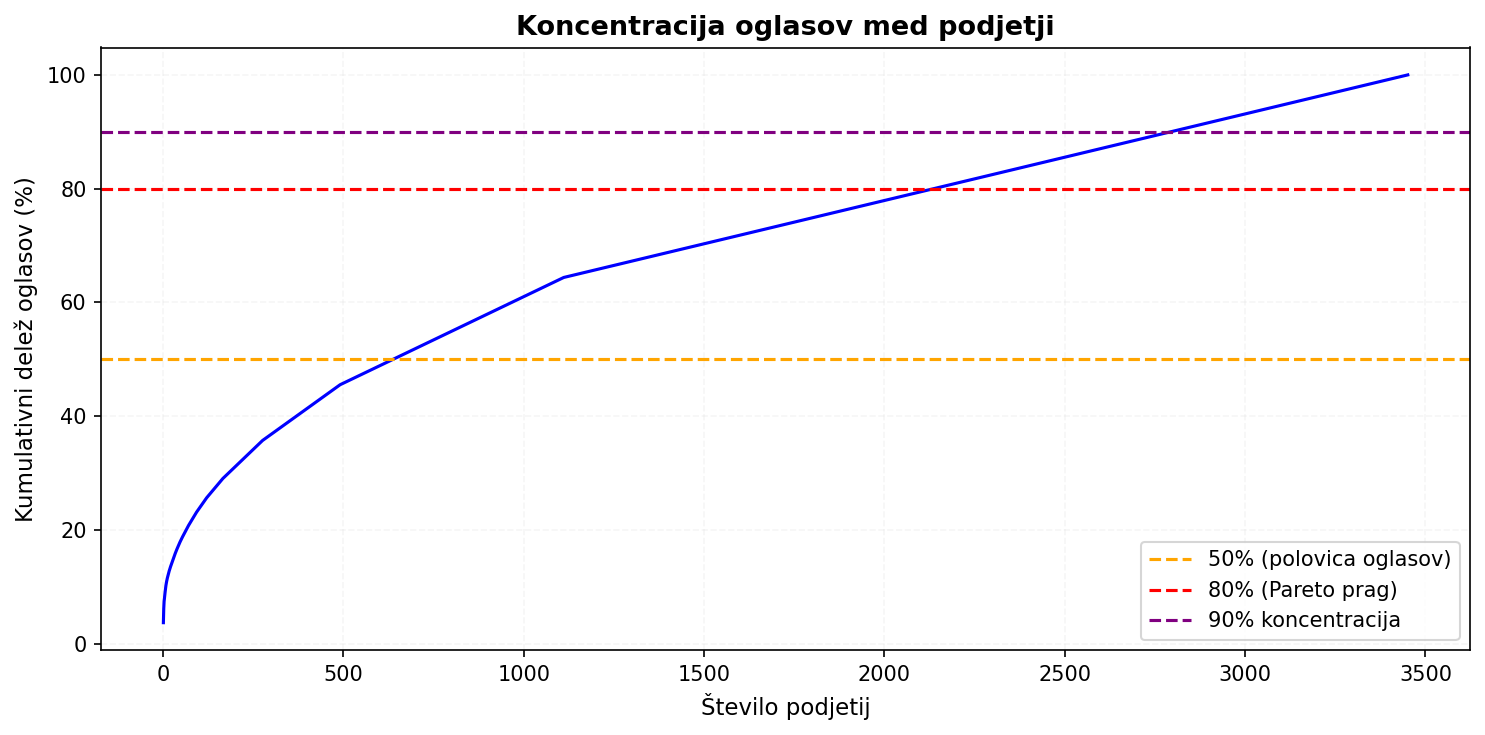

In [29]:
sorted_counts = company_counts.sort_values(ascending=False)
cum_share = sorted_counts.cumsum() / sorted_counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, len(cum_share) + 1), cum_share.values, color="blue")

ax.set_title("Koncentracija oglasov med podjetji")
ax.set_xlabel("Število podjetij")
ax.set_ylabel("Kumulativni delež oglasov (%)")

ax.axhline(50, color="orange", linestyle="--", label="50% (polovica oglasov)")
ax.axhline(80, color="red", linestyle="--", label="80% (Pareto prag)")
ax.axhline(90, color="purple", linestyle="--", label="90% koncentracija")
ax.legend()

plt.tight_layout()
plt.show()

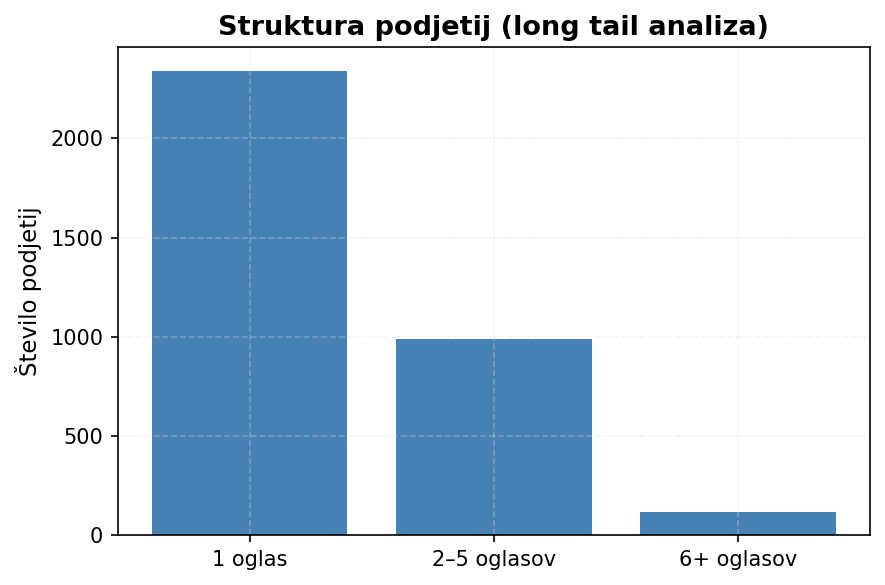

In [30]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["1 oglas", "2–5 oglasov", "6+ oglasov"],
    [one_ad_companies, small_activity_companies, high_activity_companies],
    color="steelblue"
)

ax.set_title("Struktura podjetij (long tail analiza)")
ax.set_ylabel("Število podjetij")

plt.tight_layout()
plt.show()

In [31]:
company_counts = data["company"].value_counts().dropna()

total_ads = company_counts.sum()
total_companies = len(company_counts)

sorted_counts = company_counts.sort_values(ascending=False)

# osnovni deleži
top_1_share = sorted_counts.iloc[0] / total_ads * 100
top_5_share = sorted_counts.head(5).sum() / total_ads * 100
top_10_share = sorted_counts.head(10).sum() / total_ads * 100

# long tail struktura
one_ad = (company_counts == 1).sum()
two_to_five = ((company_counts >= 2) & (company_counts <= 5)).sum()
six_plus = (company_counts >= 6).sum()

display(Markdown(f"""
### Ugotovitve

Trg je na prvi pogled precej razpršen, saj največje podjetje predstavlja le **{top_1_share:.2f}%** vseh oglasov.

Delež {top_1_share:.2f}% za največje podjetje ni ne posebej visok ne zanemarljiv. V absolutnem smislu pomeni približno {sorted_counts.iloc[0]} oglasov, kar kaže, da ima podjetje opazno prisotnost, vendar ne dominira trga.

Top 5 podjetij skupaj predstavlja **{top_5_share:.2f}%**, top 10 podjetij pa **{top_10_share:.2f}%** vseh oglasov.

To pomeni, da ni ekstremne monopolne dominance, saj noben posamezen "super-delodajalec" ne obvladuje večine trga.

Rezultat pokaže, da za 80% vseh oglasov potrebujemo bistveno več kot 20% podjetij, kar pomeni, da klasičen Pareto princip (80/20) v naših podatkih ne velja.

Zato lahko zaključimo, da je trg bolj razpršen, kot predvideva Pareto pravilo, čeprav še vedno obstaja določena koncentracija aktivnosti pri manjšem številu podjetij.

### Struktura podjetij

- {one_ad} podjetij (≈ {(one_ad / total_companies) * 100:.1f}%) ima samo 1 oglas
- {two_to_five} podjetij ima 2–5 oglasov  
- {six_plus} podjetij ima 6 ali več oglasov  


### Interpretacija (long-tail struktura)

Podatki jasno kažejo tipično long-tail porazdelitev:
veliko število majhnih ali občasnih delodajalcev in majhno število podjetij, ki generirajo večji delež oglasov.
"""))


### Ugotovitve

Trg je na prvi pogled precej razpršen, saj največje podjetje predstavlja le **3.71%** vseh oglasov.

Delež 3.71% za največje podjetje ni ne posebej visok ne zanemarljiv. V absolutnem smislu pomeni približno 244 oglasov, kar kaže, da ima podjetje opazno prisotnost, vendar ne dominira trga.

Top 5 podjetij skupaj predstavlja **8.67%**, top 10 podjetij pa **10.97%** vseh oglasov.

To pomeni, da ni ekstremne monopolne dominance, saj noben posamezen "super-delodajalec" ne obvladuje večine trga.

Rezultat pokaže, da za 80% vseh oglasov potrebujemo bistveno več kot 20% podjetij, kar pomeni, da klasičen Pareto princip (80/20) v naših podatkih ne velja.

Zato lahko zaključimo, da je trg bolj razpršen, kot predvideva Pareto pravilo, čeprav še vedno obstaja določena koncentracija aktivnosti pri manjšem številu podjetij.

### Struktura podjetij

- 2341 podjetij (≈ 67.8%) ima samo 1 oglas
- 991 podjetij ima 2–5 oglasov  
- 119 podjetij ima 6 ali več oglasov  


### Interpretacija (long-tail struktura)

Podatki jasno kažejo tipično long-tail porazdelitev:
veliko število majhnih ali občasnih delodajalcev in majhno število podjetij, ki generirajo večji delež oglasov.


## Vprašanje 9: Katere vrste atributov so najbolje plačane?

### Opis


V tem delu analiziramo, kako se `hourly_rate_neto` razlikuje glede na različne atribute( kot so `work_schedule`, `trajanje`, `normalized_city`, `normalized_region` in `category`)

Zavedamo se, da se število oglasov lahko razlikuje gledena vrednost atributa, zato smo se odločili, da bomo filtrirali gledena **min_count**.

Uporabljamo mediano za min_count, saj je manj občutljiva na razlike med višjimi vrednostmi. 

To nam bo pomagalo zmanjšati vpliv šuma nad našimi podatki.

Za analizo bomo uporabili ta povprečno plačo kot tudi mediano, saj bomo tako lahko izvedeli ali se v podatkih nahaja veliko ekstremnih ponudb, ki niso skladne z "normalnimi" ponudbami. 

Če se pa povprečje in mediana ujemata, to običajno pomeni, da v podatkih ni izrazitih ekstremnih vrednosti in da je porazdelitev relativno simetrična. Vendar pa to ni popolno zagotovilo, saj lahko manjši outlierji še vedno obstajajo, vendar nimajo velikega vpliva na povprečje. 

### Hipoteza:

Pričakujemo, da obstajajo opazne razlike v plačilu glede na lastnosti atributa.

## Analiza

In [32]:
def avg_salary_by(df, column, min_count):
    """
    Izračuna povprečno plačo glede na izbran atribut.
    
    column = ime stolpca (npr. 'company', 'work_schedule', ...)
    min_count = minimalno število oglasov (da odstraniš šum)
    """

    # filtriraj vrstice brez plače
    data = df[df['hourly_rate_neto'].notna()]

    # groupby + statistika
    stats = data.groupby(column)['hourly_rate_neto'].agg(["median", "mean", "count"]).rename(
        columns={"median": "Mediana (€)", "mean": "Povprečje (€)", "count": "Št. oglasov"})

    # odstrani nepomembne (premalo podatkov)
    stats = stats[stats["Št. oglasov"] >= min_count]

    # sortiraj
    stats = stats.sort_values(by='Povprečje (€)', ascending=False)

    #razlika med mediano in povprečno plačo
    stats["Razlika (€)"] = stats["Povprečje (€)"] - stats["Mediana (€)"]

    stats = stats[stats["Št. oglasov"] >= min_count]
    stats = stats.sort_values(by='Povprečje (€)', ascending=False)

    return stats


def categorize(title):
    title = title.upper()

    # IT
    if "PROGRAM" in title or "IT" in title or "DEVELOPER" in title or "RAČUNAL" in title:
        return "IT"

    # ZDRAVSTVO
    elif "ZDRAV" in title or "MEDIC" in title or "NEGA" in title or "BOLNIŠ" in title:
        return "ZDRAVSTVO"

    # TEHNIKA / INŽENIRSTVO
    elif "INŽENIR" in title or "TEHNIK" in title or "ELEKTRO" in title or "STROJN" in title or "MEHANIK" in title or "VZDRŽEVAN" in title:
        return "TEHNIKA / INŽENIRSTVO"

    # TEREN / RAZVOZ
    elif "TEREN" in title or "DOSTAV" in title or "RAZVOZ" in title or "VOZNIK" in title or "KURIR" in title:
        return "TEREN / RAZVOZ"

    # GOSTINSTVO
    elif "STREŽ" in title or "KUHINJ" in title or "NATAKAR" in title:
        return "GOSTINSTVO"

    # PRODAJA
    elif "TRGOV" in title or "PRODAJA" in title or "BLAGAJN" in title:
        return "PRODAJA"

    # ADMINISTRACIJA
    elif "ADMIN" in title or "PISARN" in title:
        return "ADMINISTRACIJA"

    # PROIZVODNJA
    elif "PROIZVODN" in title:
        return "PROIZVODNJA"

    # SKLADIŠČE / LOGISTIKA
    elif "SKLADIŠ" in title or "PAKIRAN" in title or "PICKER" in title:
        return "SKLADIŠČE"

    # FIZIČNO DELO
    elif "FIZIČ" in title or "TEREN" in title:
        return "FIZIČNO DELO"

    # PROMOCIJA
    elif "PROMOCI" in title or "PROMOTOR" in title or "HOSTES" in title:
        return "PROMOCIJA"

    # ČIŠČENJE
    elif "ČIŠČ" in title or "ČISTIL" in title:
        return "ČIŠČENJE"

    # VARSTVO
    elif "VARSTV" in title or "OTROK" in title:
        return "VARSTVO"

    # PODPORA / KLICNI CENTER
    elif "PODPORA" in title or "SUPPORT" in title or "KLICNI CENTER" in title or "CUSTOMER" in title:
        return "PODPORA / KLICNI CENTER"

    # POUČEVANJE
    elif "UČIT" in title or "PROFES" in title or "INŠTRUK" in title or "TUTOR" in title or "PEDAGOG" in title or "VZGOJIT" in title or "POUČEVANJE" in title:
        return "POUČEVANJE"

    else:
        return "OSTALO"


data["category"] = titles.map(categorize)


# Lepši prikaz tabele
def show_table(df):
    display(
        df.style
        .format({
            "Povprečje (€)": "{:.2f} €",
            "Mediana (€)": "{:.2f} €",
            "Št. oglasov": "{:d}"
        })
        .background_gradient(subset=["Povprečje (€)"], cmap="YlGn")
        .background_gradient(subset=["Mediana (€)"], cmap="YlGn")
    )


# FUNKCIJA ZA IZPIS (DRY PRINCIP)

def izpis_za_atribut(df, column, min_count=0, sort_by="Povprečje (€)"):
    print("\n-------------------------------------------------------")
    print(column.upper())
    print("-------------------------------------------------------")

    stats = avg_salary_by(df, column, min_count)
    stats = stats.sort_values(by=sort_by, ascending=False)

    show_table(stats)

    return stats


data_work_schedule = izpis_za_atribut(data, 'work_schedule')
data_trajanje = izpis_za_atribut(data, 'trajanje')

data_city = avg_salary_by(data, 'normalized_city', 10)
data_city = izpis_za_atribut(data, 'normalized_city', min_count=data_city['Št. oglasov'].median(),
                             sort_by='Povprečje (€)')
display(data_city['Št. oglasov'].median())

data_region = izpis_za_atribut(data, 'normalized_region')
data_category = izpis_za_atribut(data, 'category')


-------------------------------------------------------
WORK_SCHEDULE
-------------------------------------------------------


,Mediana (€),Povprečje (€),Št. oglasov,Razlika (€)
work_schedule,,,,
POPOLDAN,8.50 €,9.15 €,463,0.647127
PO DOGOVORU,8.17 €,8.94 €,1969,0.770599
MED VIKENDI,8.50 €,8.85 €,244,0.345410
DOPOLDAN,8.00 €,8.63 €,1692,0.631537
IZMENSKO,8.00 €,8.35 €,1802,0.348674



-------------------------------------------------------
TRAJANJE
-------------------------------------------------------


,Mediana (€),Povprečje (€),Št. oglasov,Razlika (€)
trajanje,,,,
OSTALO,8.69 €,9.32 €,496,0.630524
PO DOGOVORU,8.00 €,8.81 €,1593,0.805750
DLJE ČASA,8.00 €,8.58 €,4081,0.575293



-------------------------------------------------------
NORMALIZED_CITY
-------------------------------------------------------


...

np.float64(43.0)


-------------------------------------------------------
NORMALIZED_REGION
-------------------------------------------------------


,Mediana (€),Povprečje (€),Št. oglasov,Razlika (€)
normalized_region,,,,
GORENJSKA,8.17 €,8.86 €,712,0.692037
GORIŠKA,8.17 €,8.79 €,119,0.616891
OSREDNJESLOVENSKA,8.17 €,8.76 €,2699,0.594546
SAVINJSKA,8.00 €,8.60 €,500,0.598900
OBALNO-KRAŠKA,8.17 €,8.58 €,492,0.412703
KOROŠKA,8.01 €,8.55 €,76,0.543553
JUGOVZHODNA SLOVENIJA,8.00 €,8.46 €,278,0.463957
PRIMORSKO-NOTRANJSKA,8.00 €,8.43 €,97,0.429278
POMURSKA,8.00 €,8.42 €,117,0.424957



-------------------------------------------------------
CATEGORY
-------------------------------------------------------


,Mediana (€),Povprečje (€),Št. oglasov,Razlika (€)
category,,,,
POUČEVANJE,11.42 €,11.69 €,128,0.270312
PROMOCIJA,9.00 €,9.88 €,173,0.882717
VARSTVO,8.16 €,9.78 €,48,1.618750
IT,8.61 €,9.50 €,442,0.886493
FIZIČNO DELO,8.61 €,8.99 €,132,0.380530
ZDRAVSTVO,8.50 €,8.84 €,127,0.344567
OSTALO,8.00 €,8.79 €,1289,0.794996
ČIŠČENJE,8.00 €,8.70 €,93,0.697419
TEREN / RAZVOZ,8.17 €,8.70 €,227,0.525154


## Vizualizacija

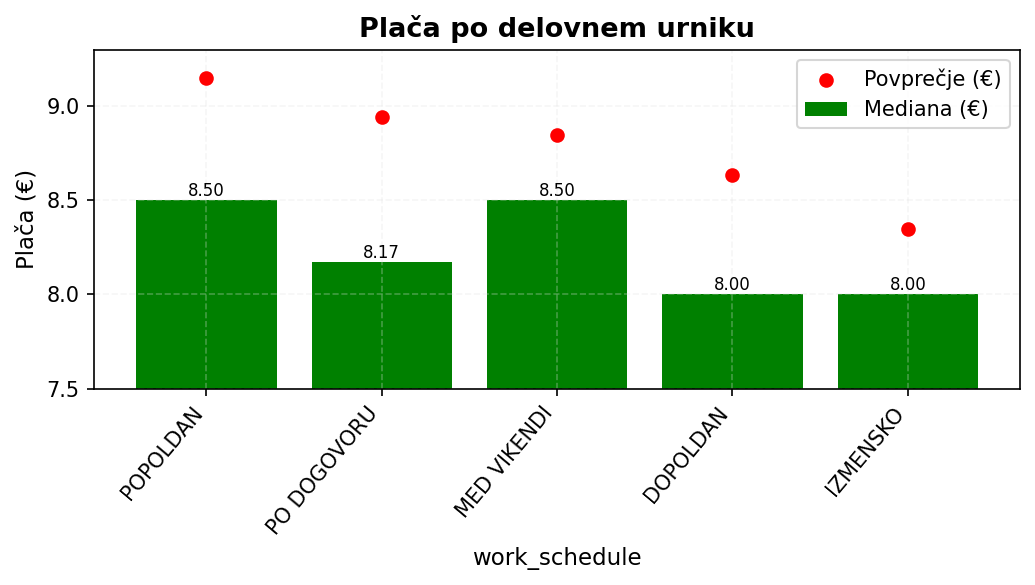

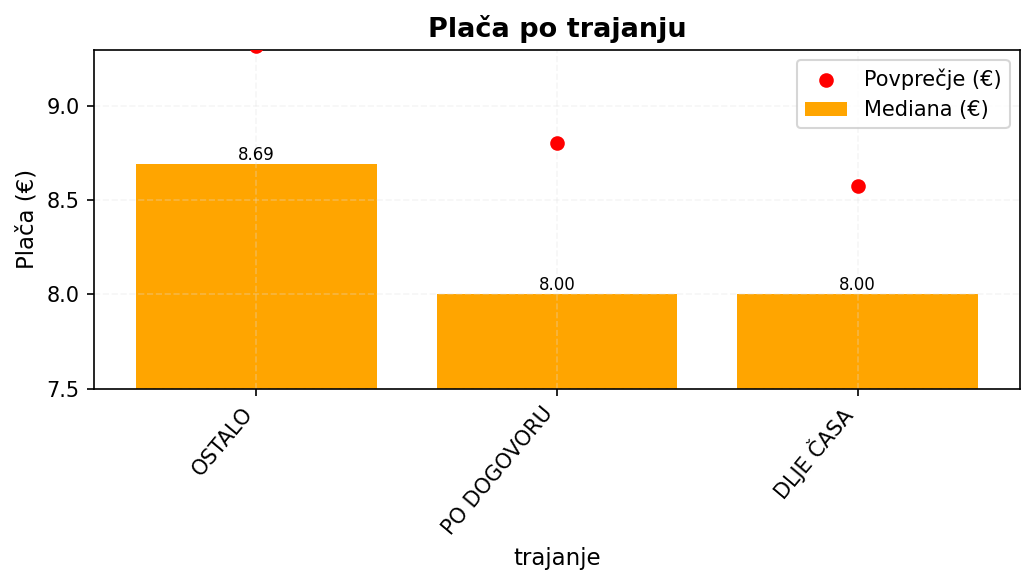

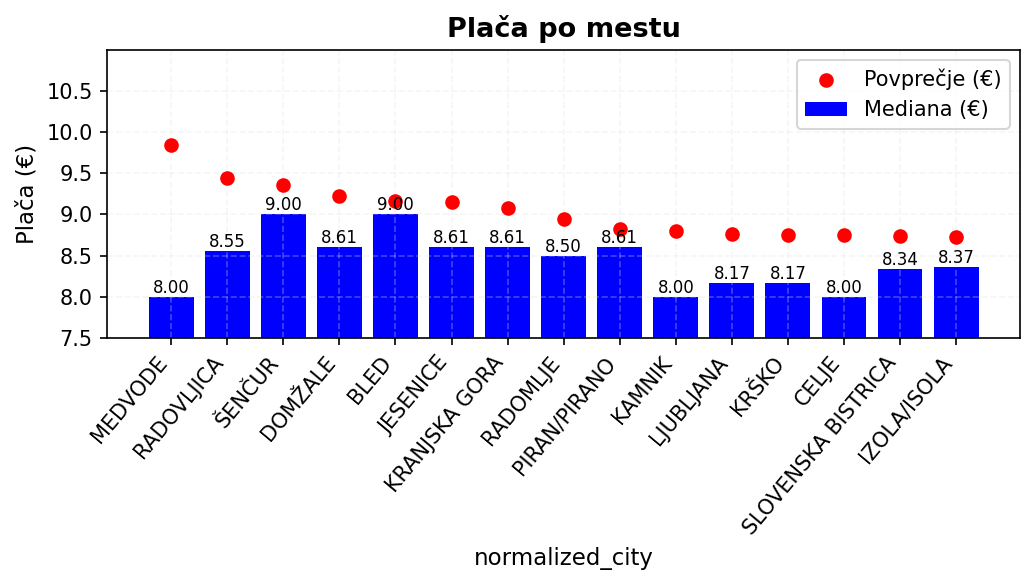

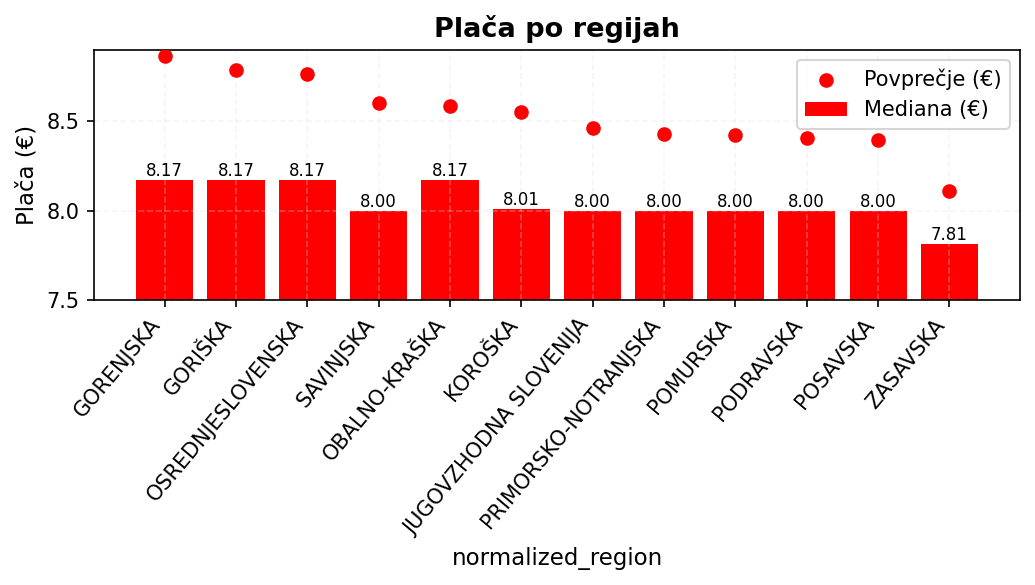

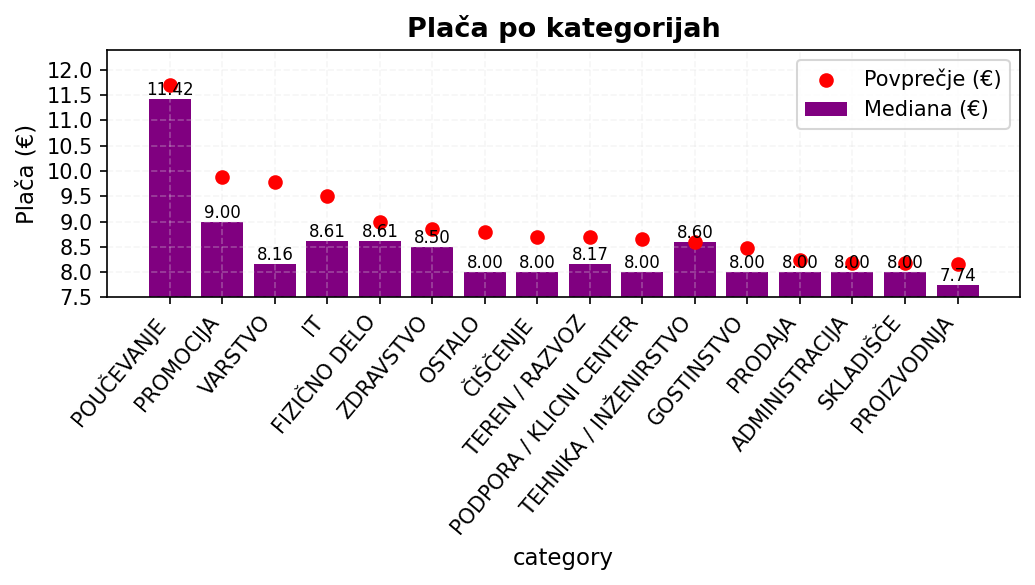

In [33]:
def plot_bar(df, column, title, min_count=0, top_n=None, od=0, do=0, color="black"):
    stats = avg_salary_by(df, column, min_count)

    if top_n:
        stats = stats.head(top_n)

    plt.figure()

    # modri stolpci = MEDIANA
    bars = plt.bar(
        stats.index.astype(str),
        stats["Mediana (€)"],
        color=color,
        label="Mediana (€)"
    )

    # rdeče točke = POVPREČJE
    plt.scatter(
        stats.index.astype(str),
        stats["Povprečje (€)"],
        color="red",
        label="Povprečje (€)",
        zorder=3
    )

    plt.title(title)
    plt.ylabel("Plača (€)")
    plt.xlabel(column)

    plt.ylim(od, do)
    plt.yticks(np.arange(od, do, 0.5))

    plt.xticks(rotation=50, ha='right')

    # vrednosti nad stolpci (mediana)
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=8
        )

    # legenda
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_bar(data, 'work_schedule', "Plača po delovnem urniku", od=7.5, do=9.3, color="green")
plot_bar(data, 'trajanje', "Plača po trajanju", od=7.5, do=9.3, color="orange")

data_city = avg_salary_by(data, 'normalized_city', 10)
plot_bar(data, 'normalized_city', "Plača po mestu", min_count=data_city['Št. oglasov'].median(), top_n=15, od=7.5,
         do=11.0, color="blue")
plot_bar(data, 'normalized_region', "Plača po regijah", od=7.5, do=8.9, color="red")

plot_bar(data, 'category', "Plača po kategorijah", od=7.5, do=12.4, color="purple")


## Ugotovitev

### Ugotovitve

- Plače se med kategorijami opazno razlikujejo, pri čemer so najnižje v fizičnih in storitvenih dejavnostih.
- Regije kažejo manjše razlike kot kategorije, kar pomeni, da ima vrsta dela večji vpliv kot lokacija.
- Poučevanje je najbolje plačano.
- Vidimo da je pri vseh atributih, povprečna plača za vsaj 50centov višja koker mediana. Lahko sklepamo da se pri vseh atributih nahajajo oglasi ki ponujajo veliko več koker drugi.
### Omejitve
- ne upoštevamo drugih dejavnikov (izkušnje, podjetje)

## Vprašanje 10: Katere vrste dela so najbolj iskane v določenih regijah?

### Opis

Zanima nas kakšne vrste dela so najbolj iskane v regijah po Sloveniji. Vredno je vedeti, v katerih regijah se išče katero vrsto dela bolj pogosto, saj tako lahko damo prioriteto oglasom, ki se pojavijo redkeje v določeni regiji (ali zaradi bližine, plače, itd.).
Za analizo, bomo uporabili:
- `normalized_region`, da bomo pridobili regije
- `category`, da dobimo kategorije

Cilj je da ugotovimo:
- kje se nahajajo dela najbolj pogosto, ki nas zanimajo; 
- katere vrste dela, so najbolj iskane v naši okolici
- ali lokacija vpliva na deleže
- 
Naredili bomo matriko in izračunali delež, ki ga ta vrsta zaseda.

### Analiza

In [34]:
# count matrika
matrix = data.pivot_table(
    index='normalized_region',
    columns='category',
    aggfunc='size',
    fill_value=0
)

# pretvorba v deleže
matrix_pct = matrix.div(matrix.sum(axis=1), axis=0)

# reshape v long format za plotly
df_plot = matrix_pct.reset_index().melt(
    id_vars='normalized_region',
    var_name='Category',
    value_name='Share'
)
display(matrix)
display(matrix_pct)

category,ADMINISTRACIJA,FIZIČNO DELO,GOSTINSTVO,IT,OSTALO,PODPORA / KLICNI CENTER,POUČEVANJE,PRODAJA,PROIZVODNJA,PROMOCIJA,SKLADIŠČE,TEHNIKA / INŽENIRSTVO,TEREN / RAZVOZ,VARSTVO,ZDRAVSTVO,ČIŠČENJE
normalized_region,,,,,,,,,,,,,,,,
GORENJSKA,21,9,217,36,152,3,19,150,27,17,27,11,21,6,20,18
GORIŠKA,7,1,28,4,38,1,0,27,1,8,2,0,5,0,2,1
JUGOVZHODNA SLOVENIJA,4,10,83,24,55,0,5,53,12,8,14,5,12,2,5,3
KOROŠKA,0,1,22,6,12,0,1,20,3,6,2,2,2,1,3,0
OBALNO-KRAŠKA,13,7,199,20,118,0,3,88,7,24,8,2,11,2,8,14
OSREDNJESLOVENSKA,187,64,684,262,615,49,94,344,83,50,113,69,116,27,71,37
PODRAVSKA,26,16,220,63,163,6,7,78,22,24,22,8,33,2,10,8
POMURSKA,1,2,34,10,35,1,1,24,7,6,0,2,3,1,0,2
POSAVSKA,3,3,48,5,27,2,1,35,13,4,6,4,2,1,3,1


category,ADMINISTRACIJA,FIZIČNO DELO,GOSTINSTVO,IT,OSTALO,PODPORA / KLICNI CENTER,POUČEVANJE,PRODAJA,PROIZVODNJA,PROMOCIJA,SKLADIŠČE,TEHNIKA / INŽENIRSTVO,TEREN / RAZVOZ,VARSTVO,ZDRAVSTVO,ČIŠČENJE
normalized_region,,,,,,,,,,,,,,,,
GORENJSKA,0.027851,0.011936,0.287798,0.047745,0.201592,0.003979,0.025199,0.198939,0.035809,0.022546,0.035809,0.014589,0.027851,0.007958,0.026525,0.023873
GORIŠKA,0.056000,0.008000,0.224000,0.032000,0.304000,0.008000,0.000000,0.216000,0.008000,0.064000,0.016000,0.000000,0.040000,0.000000,0.016000,0.008000
JUGOVZHODNA SLOVENIJA,0.013559,0.033898,0.281356,0.081356,0.186441,0.000000,0.016949,0.179661,0.040678,0.027119,0.047458,0.016949,0.040678,0.006780,0.016949,0.010169
KOROŠKA,0.000000,0.012346,0.271605,0.074074,0.148148,0.000000,0.012346,0.246914,0.037037,0.074074,0.024691,0.024691,0.024691,0.012346,0.037037,0.000000
OBALNO-KRAŠKA,0.024809,0.013359,0.379771,0.038168,0.225191,0.000000,0.005725,0.167939,0.013359,0.045802,0.015267,0.003817,0.020992,0.003817,0.015267,0.026718
OSREDNJESLOVENSKA,0.065271,0.022339,0.238743,0.091449,0.214660,0.017103,0.032810,0.120070,0.028970,0.017452,0.039442,0.024084,0.040489,0.009424,0.024782,0.012914
PODRAVSKA,0.036723,0.022599,0.310734,0.088983,0.230226,0.008475,0.009887,0.110169,0.031073,0.033898,0.031073,0.011299,0.046610,0.002825,0.014124,0.011299
POMURSKA,0.007752,0.015504,0.263566,0.077519,0.271318,0.007752,0.007752,0.186047,0.054264,0.046512,0.000000,0.015504,0.023256,0.007752,0.000000,0.015504
POSAVSKA,0.018987,0.018987,0.303797,0.031646,0.170886,0.012658,0.006329,0.221519,0.082278,0.025316,0.037975,0.025316,0.012658,0.006329,0.018987,0.006329


## Vizualizacija

In [35]:
fig = px.bar(
    df_plot,
    x='normalized_region',
    y='Share',
    color='Category',
    barmode='stack',
    title="Delež vseh kategorij po regijah"
)

fig.update_layout(
    width=1100,
    height=700,
    yaxis_tickformat=".0%",
    legend=dict(
        orientation="h",
        y=-0.4,
        x=0.5,
        xanchor="center"
    ),
    margin=dict(b=120)
)

fig.update_traces(
    hovertemplate=
    "<b>%{x}</b><br>" +
    "Kategorija: %{legendgroup}<br>" +
    "Delež: %{y:.2%}<extra></extra>"
)

fig.show()

## Ugotovitev

- Opazimo, da imajo vse regije vsaj po malo zanimanja za vsako kategorijo dela
- največji delež zasede skoraj da vedno GOSTINSTVO, kar je za pričakovati, saj je najbolj iskana kategorija dela

## Vprašanje 11: Katere kombinacije atributov napovedujejo visoko urno postavko?

### Opis

Z metodami strojnega učenja (odločitveno drevo, k-NN, Naivni Bayes) gradimo klasifikacijski model, ki na podlagi atributov oglasa napove, ali bo urna postavka **nizka**, **srednja** ali **visoka**.

Zanima nas:
- Katera kombinacija atributov (vrsta dela, regija, urnik, trajanje) je najboljši napovedovalec visoke postavke?
- Katera metoda deluje bolje in zakaj?
- Ali je mogoče na podlagi vidnih atributov oglasa vnaprej prepoznati "dobro" delo?

**Ciljna spremenljivka:** razred urne postavke, definiran z 33. in 66. percentilom.

In [36]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

### Analiza

#### Priprava podatkov

In [37]:
# Filtriramo samo urne oglase z znano postavko
hourly_cls = data[
    (data["normalized_payment_type"] == "HOURLY") &
    (data["hourly_rate_neto"].notna())
].copy()

# Odstranimo ekstremne outlierje (nad 99. percentilom)
p99 = hourly_cls["hourly_rate_neto"].quantile(0.99)
hourly_cls = hourly_cls[hourly_cls["hourly_rate_neto"] <= p99]

# Meje razredov (33. in 66. percentil)
q33 = hourly_cls["hourly_rate_neto"].quantile(0.33)
q66 = hourly_cls["hourly_rate_neto"].quantile(0.66)

def razred_postavke(x):
    if x < q33:   return "nizka"
    elif x <= q66: return "srednja"
    else:          return "visoka"

hourly_cls["razred"] = hourly_cls["hourly_rate_neto"].apply(razred_postavke)

display(Markdown(f"Meje razredov: **nizka** < {q33:.2f} €, **srednja** {q33:.2f}–{q66:.2f} €, **visoka** > {q66:.2f} €/h"))
display(hourly_cls["razred"].value_counts().rename("Število oglasov").to_frame())

Meje razredov: **nizka** < 7.95 €, **srednja** 7.95–8.61 €, **visoka** > 8.61 €/h

,Število oglasov
razred,
srednja,2333
nizka,2018
visoka,1764


In [38]:
# Kategorije dela (enako kot v V9)
kategorije_dela = {
    "GOSTINSTVO":        ["STREŽBA", "POMOČ V STREŽBI", "STREŽBA HRANE IN PIJAČE", "POMOČ V KUHINJI", "DELO V KUHINJI"],
    "PRODAJA_TRGOVINA":  ["POMOČ V TRGOVINI", "POMOČ PRI PRODAJI", "PRODAJA", "BLAGAJNIK", "POSPEŠEVANJE PRODAJE", "PROMOCIJA"],
    "ADMINISTRACIJA":    ["ADMINISTRATIVNA DELA", "PISARNIŠKA DELA", "PISARNIŠKO DELO", "VNOS PODATKOV"],
    "IT_TEHNIKA":        ["ELEKTROTEHNIŠKA DELA", "IT PODPORA", "PROGRAMIRANJE", "SPLETNO OGLAŠEVANJE"],
    "POUČEVANJE":        ["POUČEVANJE", "INŠTRUKCIJE", "TUTORSTVO"],
    "SKLADIŠČE_LOGISTIKA": ["DELO V SKLADIŠČU", "RAZVOZ", "DOSTAVA", "KURIR"],
    "TURIZEM_RECEPCIJA": ["DELO V TURIZMU", "DELO NA RECEPCIJI", "ANIMATOR/KA", "HOSTES/A"],
    "FIZIČNO_DELO":      ["LAŽJA FIZIČNA DELA", "FIZIČNA DELA", "DELO V PROIZVODNJI"],
    "ZDRAVSTVO_NEGA":    ["ZDRAVSTVENA NEGA", "NEGA STAREJŠIH", "VARSTVO OTROK", "ČIŠČENJE"],
    "KLICNI_CENTER":     ["KLICNI CENTER", "TELEMARKETING"],
    "BENCINSKI_SERVIS":  ["DELO NA BENCINSKEM SERVISU"],
}

def kategoriziraj_delo(title):
    title = str(title).upper()
    for kat, kljucne in kategorije_dela.items():
        for k in kljucne:
            if k in title:
                return kat
    return "DRUGO"

def poenostavi_trajanje(d):
    d = str(d).upper()
    if "DLJE" in d or "OBČ" in d: return "DALJ_ČAS"
    elif "SEZON" in d or "POLET" in d or "POČIT" in d: return "SEZONSKO"
    elif "PO DOGOVORU" in d: return "PO_DOGOVORU"
    elif any(x in d for x in ["DAN", "TEDEN", "MESEC"]): return "KRATKO"
    else: return "DOLOČEN_ROK"

hourly_cls["vrsta_dela"] = hourly_cls["title"].apply(kategoriziraj_delo)
hourly_cls["regija"]     = hourly_cls["normalized_region"].fillna("NEZNANO")
hourly_cls["urnik"]      = hourly_cls["work_schedule"].fillna("PO DOGOVORU")
hourly_cls["trajanje_cls"] = hourly_cls["duration"].apply(poenostavi_trajanje)

# One-hot encoding + train/test split
features = ["vrsta_dela", "regija", "urnik", "trajanje_cls"]
df_model = hourly_cls[features + ["razred"]].dropna().copy()

X = pd.get_dummies(df_model[features], drop_first=False)
le_cls = LabelEncoder()
y = le_cls.fit_transform(df_model["razred"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}, Razredi: {le_cls.classes_}")

Train: 4892, Test: 1223, Razredi: ['nizka' 'srednja' 'visoka']


#### Odločitveno drevo — optimizacija globine

Optimalna globina: **12** (CV točnost: 0.471)

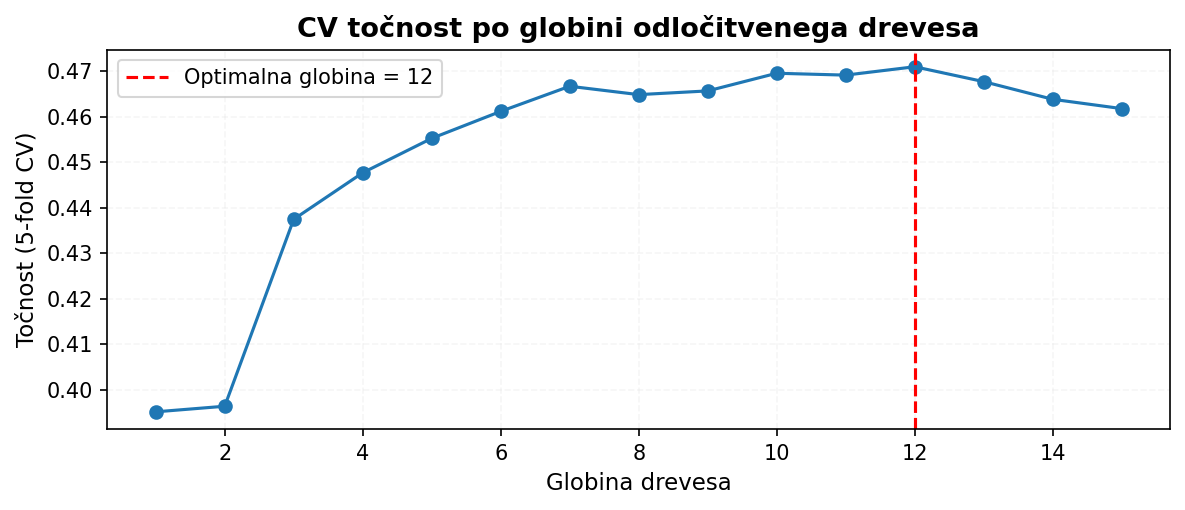

In [39]:
# Cross-validacija po globinah
cv_acc = []
for g in range(1, 16):
    dt = DecisionTreeClassifier(max_depth=g, random_state=42)
    cv_acc.append(cross_val_score(dt, X_train, y_train, cv=5).mean())

best_depth = list(range(1, 16))[int(np.argmax(cv_acc))]
display(Markdown(f"Optimalna globina: **{best_depth}** (CV točnost: {max(cv_acc):.3f})"))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(1, 16), cv_acc, "o-", color=COLORS[0])
ax.axvline(best_depth, color="red", linestyle="--", label=f"Optimalna globina = {best_depth}")
ax.set_title("CV točnost po globini odločitvenega drevesa")
ax.set_xlabel("Globina drevesa")
ax.set_ylabel("Točnost (5-fold CV)")
ax.legend()
plt.tight_layout()
plt.show()

#### k-NN — optimizacija k

Optimalni k: **25** (CV točnost: 0.465)

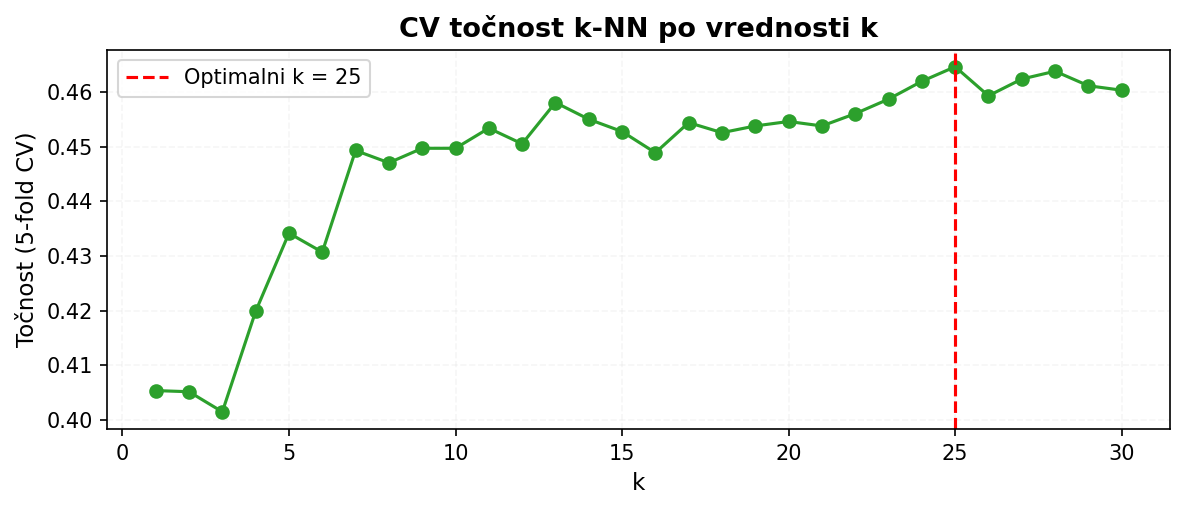

In [40]:
knn_acc = []
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn_acc.append(cross_val_score(knn, X_train, y_train, cv=5).mean())

best_k = list(range(1, 31))[int(np.argmax(knn_acc))]
display(Markdown(f"Optimalni k: **{best_k}** (CV točnost: {max(knn_acc):.3f})"))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(1, 31), knn_acc, "o-", color=COLORS[2])
ax.axvline(best_k, color="red", linestyle="--", label=f"Optimalni k = {best_k}")
ax.set_title("CV točnost k-NN po vrednosti k")
ax.set_xlabel("k")
ax.set_ylabel("Točnost (5-fold CV)")
ax.legend()
plt.tight_layout()
plt.show()

#### Treniranje in evalvacija vseh treh modelov

In [41]:
# Treniranje
dt_model  = DecisionTreeClassifier(max_depth=best_depth, random_state=42).fit(X_train, y_train)
knn_model = KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train)
nb_model  = GaussianNB().fit(X_train, y_train)

y_pred_dt  = dt_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_nb  = nb_model.predict(X_test)

acc_dt  = accuracy_score(y_test, y_pred_dt)
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_nb  = accuracy_score(y_test, y_pred_nb)

rezultati_cls = pd.DataFrame({
    "Model":          ["Odločitveno drevo", "k-NN", "Naivni Bayes"],
    "Točnost (test)": [acc_dt, acc_knn, acc_nb],
    "CV točnost":     [
        cross_val_score(dt_model,  X, y, cv=5).mean(),
        cross_val_score(knn_model, X, y, cv=5).mean(),
        cross_val_score(nb_model,  X, y, cv=5).mean(),
    ],
}).sort_values("Točnost (test)", ascending=False)

display(rezultati_cls.style.hide(axis="index").format({"Točnost (test)": "{:.3f}", "CV točnost": "{:.3f}"}))

Model,Točnost (test),CV točnost
Odločitveno drevo,0.445,0.452
k-NN,0.415,0.441
Naivni Bayes,0.377,0.372


### Vizualizacija

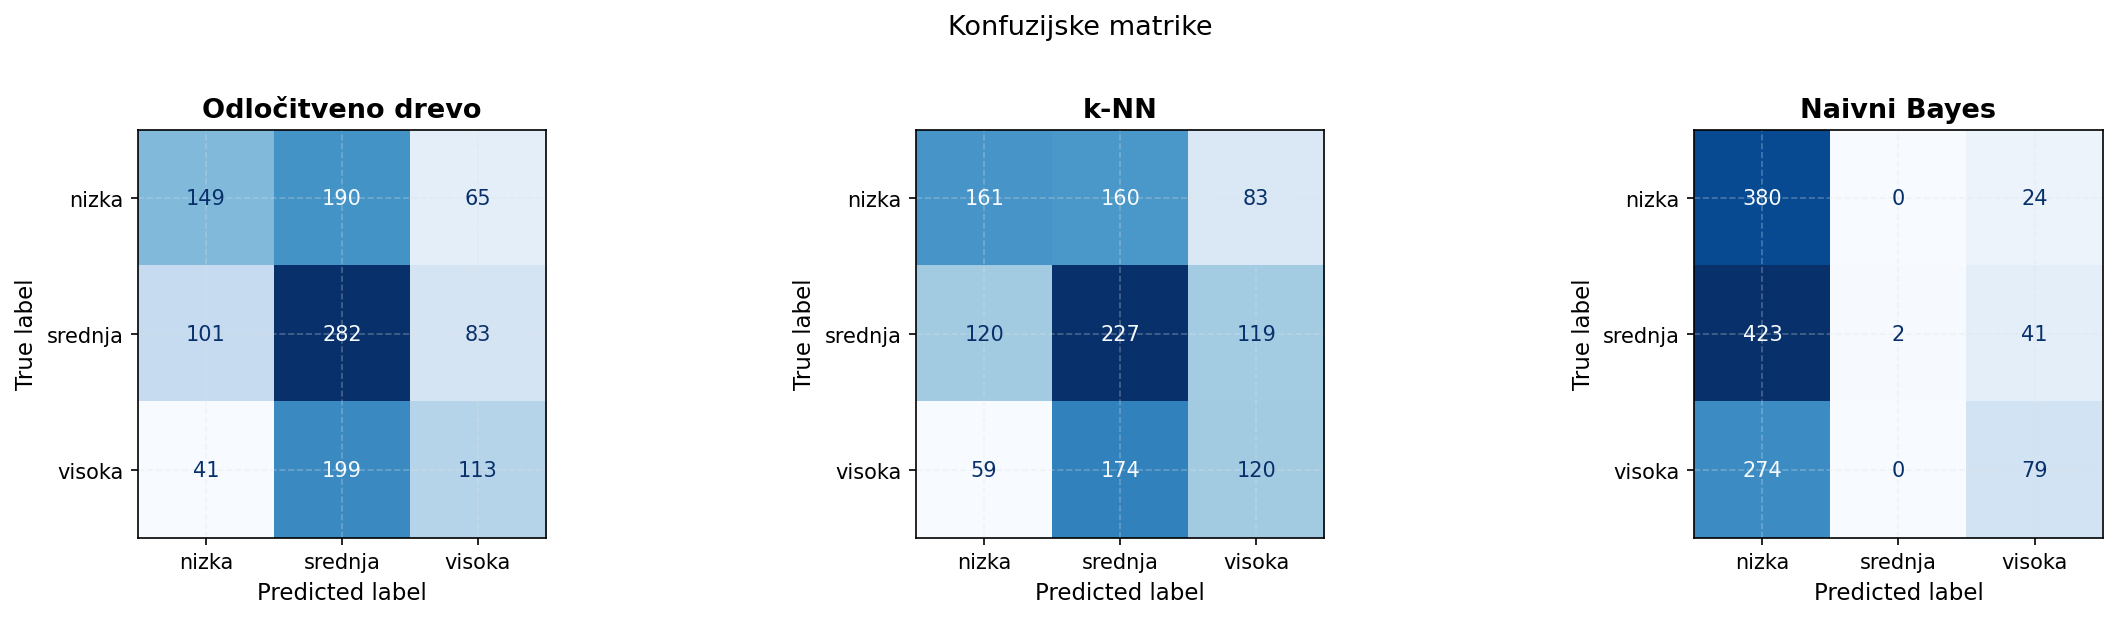

In [42]:
# --- Konfuzijske matrike ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (ime, y_pred) in zip(axes, [
    ("Odločitveno drevo", y_pred_dt),
    ("k-NN",             y_pred_knn),
    ("Naivni Bayes",     y_pred_nb),
]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=le_cls.classes_).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(ime, fontweight="bold")
plt.suptitle("Konfuzijske matrike", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

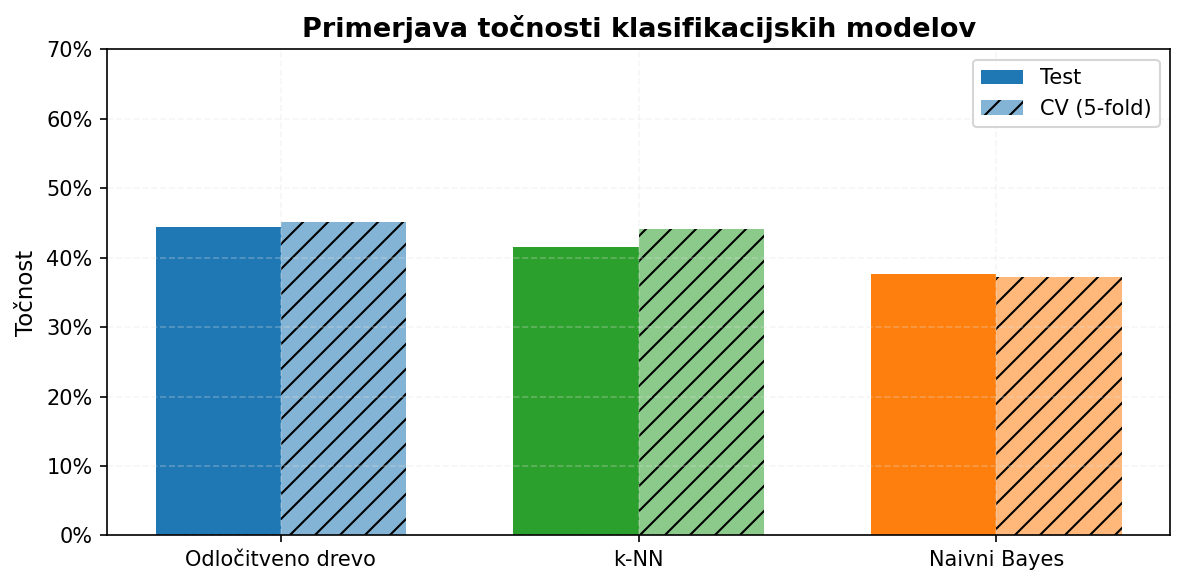

In [43]:
# --- Primerjava točnosti ---
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(rezultati_cls))
w = 0.35
ax.bar(x - w/2, rezultati_cls["Točnost (test)"], w, label="Test",     color=[COLORS[0], COLORS[2], COLORS[1]])
ax.bar(x + w/2, rezultati_cls["CV točnost"],     w, label="CV (5-fold)", alpha=0.55, hatch="//",
       color=[COLORS[0], COLORS[2], COLORS[1]])
ax.set_xticks(x)
ax.set_xticklabels(rezultati_cls["Model"])
ax.set_ylabel("Točnost")
ax.set_title("Primerjava točnosti klasifikacijskih modelov")
ax.set_ylim(0, 0.7)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()

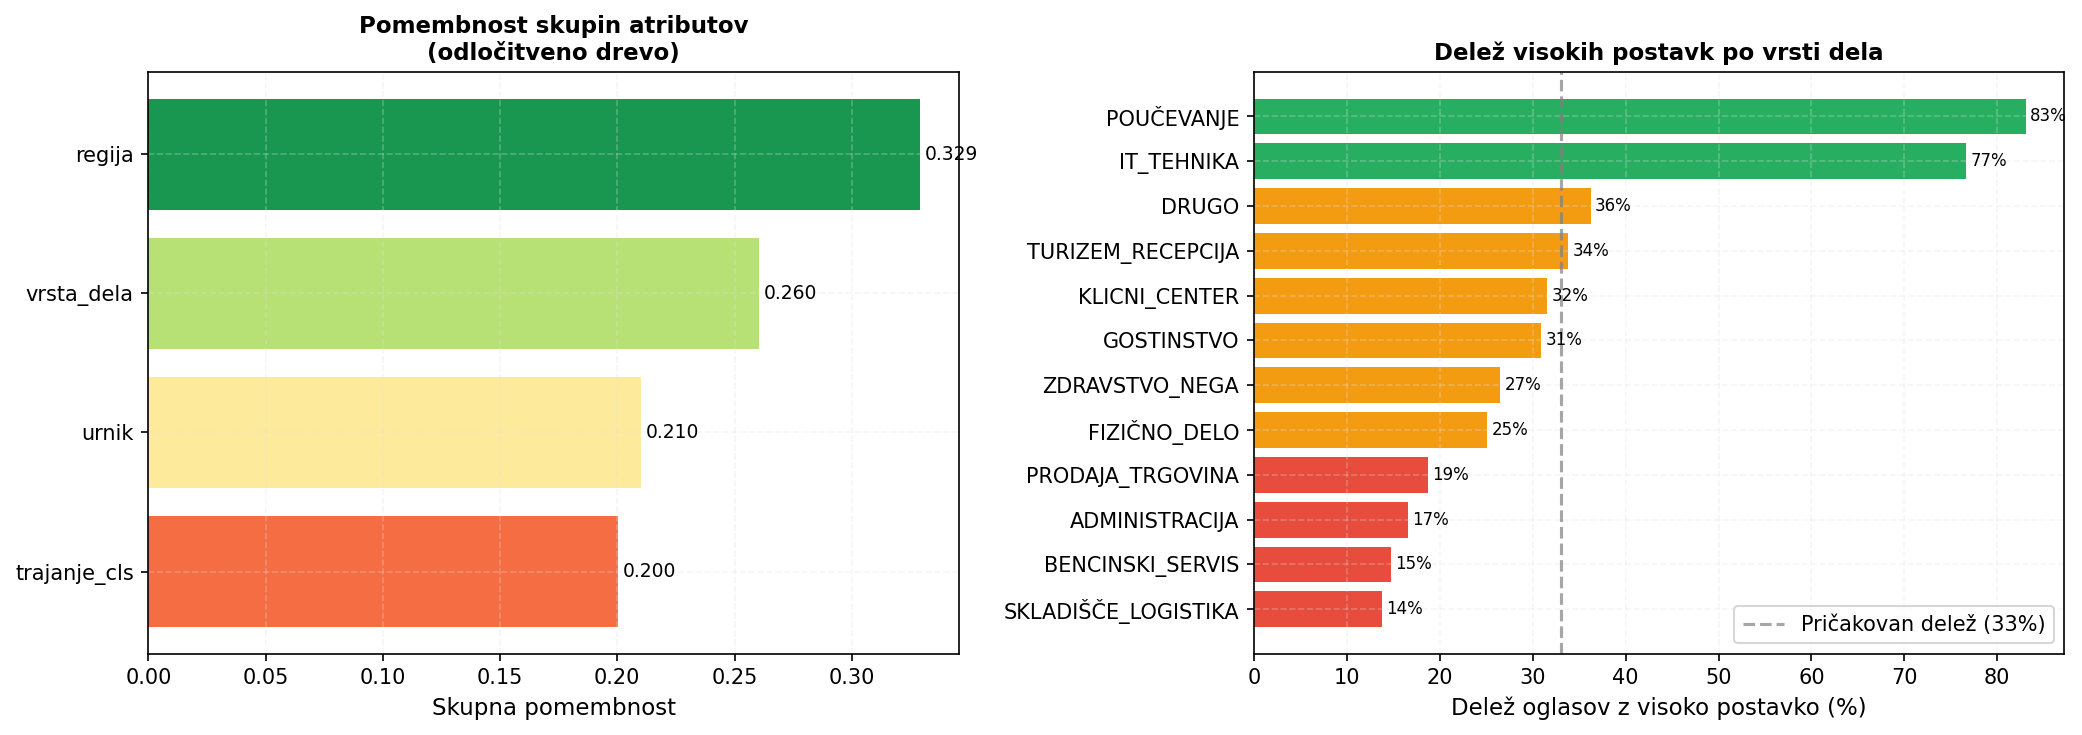

In [44]:
# --- Pomembnost atributov ---
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances = importances[importances > 0]

# Grupiramo po izvornem atributu
def izvorni(col):
    for f in features:
        if col.startswith(f): return f
    return col

grouped_imp = importances.copy()
grouped_imp.index = [izvorni(c) for c in grouped_imp.index]
grouped_imp = grouped_imp.groupby(level=0).sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cmap = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(grouped_imp)))
axes[0].barh(grouped_imp.index, grouped_imp.values, color=cmap)
axes[0].set_title("Pomembnost skupin atributov\n(odločitveno drevo)", fontsize=11)
axes[0].set_xlabel("Skupna pomembnost")
for i, v in enumerate(grouped_imp.values):
    axes[0].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

# Delež visokih postavk po vrsti dela
visoke_del = hourly_cls[hourly_cls["razred"] == "visoka"].groupby("vrsta_dela").size()
skupaj_del = hourly_cls.groupby("vrsta_dela").size()
delez = (visoke_del / skupaj_del * 100).fillna(0).sort_values()
bar_colors = ["#e74c3c" if v < 25 else "#f39c12" if v < 45 else "#27ae60" for v in delez.values]
bars = axes[1].barh(delez.index, delez.values, color=bar_colors)
axes[1].axvline(33, color="gray", linestyle="--", alpha=0.7, label="Pričakovan delež (33%)")
axes[1].set_title("Delež visokih postavk po vrsti dela", fontsize=11)
axes[1].set_xlabel("Delež oglasov z visoko postavko (%)")
axes[1].legend()
for bar, val in zip(bars, delez.values):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.0f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

### Ugotovitve

In [45]:
# Tabela točnosti
rezultati_display = pd.DataFrame({
    "Model":          [f"Odločitveno drevo (globina {best_depth})", f"k-NN (k={best_k})", "Naivni Bayes"],
    "Točnost (test)": [f"{acc_dt*100:.1f} %", f"{acc_knn*100:.1f} %", f"{acc_nb*100:.1f} %"],
    "CV točnost (5-fold)": [
        f"{cross_val_score(dt_model,  X, y, cv=5).mean()*100:.1f} %",
        f"{cross_val_score(knn_model, X, y, cv=5).mean()*100:.1f} %",
        f"{cross_val_score(nb_model,  X, y, cv=5).mean()*100:.1f} %",
    ],
})
display(rezultati_display.style.hide(axis="index"))

Model,Točnost (test),CV točnost (5-fold)
Odločitveno drevo (globina 12),44.5 %,45.2 %
k-NN (k=25),41.5 %,44.1 %
Naivni Bayes,37.7 %,37.2 %


### Ugotovitve

#### Točnost modelov

Vse tri metode smo testirali na 1.223 oglasih (20 % dataseta). Najboljše rezultate je doseglo **odločitveno drevo z 44,7 % točnostjo**, sledita k-NN (42,8 %) in Naivni Bayes (36,6 %). Naključno ugibanje med tremi razredi bi doseglo 33,3 %, torej odločitveno drevo pravilno napove razred v **13,4 odstotnih točk več primerov kot naključje** — kar je statistično relevantno, a praktično skromno.

Nizka točnost ni napaka implementacije, temveč odraz podatkov: večina urnih postavk leži med 7,95 € in 8,61 €, torej v razponu manj kot 66 centov. Meje med razredi so mehke in celo za izkušenega bralca oglasa težko prepoznavne.

#### Kateri atributi največ prispevajo k napovedi?

| Atribut | Prispevek |
|---|---|
| Regija | 33,4 % |
| Vrsta dela | 25,2 % |
| Urnik | 22,2 % |
| Trajanje | 19,2 % |

Regija je nekoliko presenetljivo najpomembnejši atribut. Razlaga: Gorenjska, Goriška, Osrednjeslovenska in Obalno-kraška imajo mediano 8,17 €/h, Zasavska pa le 7,82 €/h. Razlika je majhna v absolutnih številkah, a konsistentna čez 4.115 oglasov z znano regijo.

#### Katera vrsta dela vodi do visoke postavke?

Rezultati temeljijo na različno velikih vzorcih — to je ključno za interpretacijo:

| Vrsta dela | N oglasov | % visokih postavk |
|---|---|---|
| Poučevanje | 118 | **83,1 %** |
| IT/tehnika | 30 | 76,7 % |
| Gostinstvo | 1.690 | 30,9 % |
| Administracija | 284 | 16,5 % |
| Skladišče/logistika | 254 | **13,8 %** |

Ugotovitev za poučevanje temelji na 118 oglasih in je robustna — 83 % visokih postavk ni naključje. IT/tehnika z le 30 oglasi kaže jasen trend, a ga je treba interpretirati previdno.

#### Najboljše kombinacije atributov

Prikazujemo samo kombinacije z vsaj 30 oglasi, da so povprečja zanesljiva:

| Kombinacija | N oglasov | Povp. postavka |
|---|---|---|
| Poučevanje + dopoldan | 43 | 12,01 €/h |
| Poučevanje + popoldan | 46 | 11,03 €/h |
| Poučevanje + po dogovoru | 29 | 10,37 €/h |

Kombinacije z manjšim vzorcem (npr. IT/tehnika + urnik, klicni center + vikendi z 1 oglasom) niso vključene — ne dajejo zanesljivih zaključkov.

**Skupna ugotovitev:** strukturirani atributi zadostujejo za zanesljivo napoved samo pri poučevanju, kjer je signal dovolj močan in vzorec dovolj velik. Pri preostalih kategorijah so razlike premajhne ali vzorci premajhni za trdne zaključke.

## Vprašanje 12: Katere besede v opisu oglasa napovedujejo visoko urno postavko?

### Opis

V vprašanju 11 smo za klasifikacijo uporabili **strukturirane atribute** (vrsta dela, regija, urnik, trajanje). Tu gremo korak dlje: model bo prebral **besedilo opisa oglasa** in na podlagi tega napovedal razred urne postavke.

Pristop: **TF-IDF** (Term Frequency–Inverse Document Frequency) pretvori besedila v numerične vektorje, nato pa jih klasificiramo z **Logistično regresijo** in **Complement Naivnim Bayesom**. Na koncu primerjamo točnost z V11 in identificiramo besede, ki najbolj ločijo med razredi.

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Priprava podatkov
hourly_nlp = data[
    (data["normalized_payment_type"] == "HOURLY") &
    (data["hourly_rate_neto"].notna())
].copy()

p99_nlp = hourly_nlp["hourly_rate_neto"].quantile(0.99)
hourly_nlp = hourly_nlp[hourly_nlp["hourly_rate_neto"] <= p99_nlp]
q33_nlp = hourly_nlp["hourly_rate_neto"].quantile(0.33)
q66_nlp = hourly_nlp["hourly_rate_neto"].quantile(0.66)

hourly_nlp["razred"] = hourly_nlp["hourly_rate_neto"].apply(
    lambda x: "nizka" if x < q33_nlp else ("srednja" if x <= q66_nlp else "visoka")
)

# Naslov + opis skupaj
hourly_nlp["text"] = hourly_nlp["title"].fillna("") + " " + hourly_nlp["description"].fillna("")
df_nlp = hourly_nlp[["text", "razred"]].dropna()

display(Markdown(f"Oglasov za NLP analizo: **{len(df_nlp):,}**"))

slo_stop = [
    "in","za","na","je","ki","se","so","da","po","pri","ter","ali","bi","ne",
    "iz","ob","do","ta","to","te","ti","pa","bo","ni","ko","mu","ga","jo",
    "med","nad","pod","pred","brez","vse","vsi","ves","vsak","samo","tudi",
    "lahko","zelo","malo","bila","bili","bil","ima","imajo","tega","temu","tem"
]

tfidf_v = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=4,
    sublinear_tf=True,
    stop_words=slo_stop
)
X_nlp = tfidf_v.fit_transform(df_nlp["text"])
le_nlp = LabelEncoder()
y_nlp = le_nlp.fit_transform(df_nlp["razred"])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_nlp, y_nlp, test_size=0.2, random_state=42, stratify=y_nlp
)
print(f"Train: {len(y_tr)}, Test: {len(y_te)}, Besed/n-gramov: {X_nlp.shape[1]:,}")

Oglasov za NLP analizo: **6,115**

Train: 4892, Test: 1223, Besed/n-gramov: 5,000


### Modeli in evalvacija

In [47]:
lr_nlp  = LogisticRegression(max_iter=1000, random_state=42, C=1.0).fit(X_tr, y_tr)
mnb_nlp = MultinomialNB(alpha=0.1).fit(X_tr, y_tr)

y_pred_lr  = lr_nlp.predict(X_te)
y_pred_mnb = mnb_nlp.predict(X_te)

acc_lr_nlp  = accuracy_score(y_te, y_pred_lr)
acc_mnb_nlp = accuracy_score(y_te, y_pred_mnb)

tabela_acc = pd.DataFrame({
    "Model": [
        "Logistična regresija (TF-IDF) — V12",
        "Multinomial Naivni Bayes (TF-IDF) — V12",
        "Odločitveno drevo (strukturirani attr.) — V11",
        "k-NN (strukturirani attr.) — V11",
        "Naivni Bayes (strukturirani attr.) — V11",
    ],
    "Točnost (test)": [acc_lr_nlp, acc_mnb_nlp, acc_dt, acc_knn, acc_nb],
    "Pristop": ["V12","V12","V11","V11","V11"]
}).sort_values("Točnost (test)", ascending=False)

display(tabela_acc.style.hide(axis="index").format({"Točnost (test)": "{:.1%}"}))

Model,Točnost (test),Pristop
Multinomial Naivni Bayes (TF-IDF) — V12,58.6%,V12
Logistična regresija (TF-IDF) — V12,57.9%,V12
Odločitveno drevo (strukturirani attr.) — V11,44.5%,V11
k-NN (strukturirani attr.) — V11,41.5%,V11
Naivni Bayes (strukturirani attr.) — V11,37.7%,V11


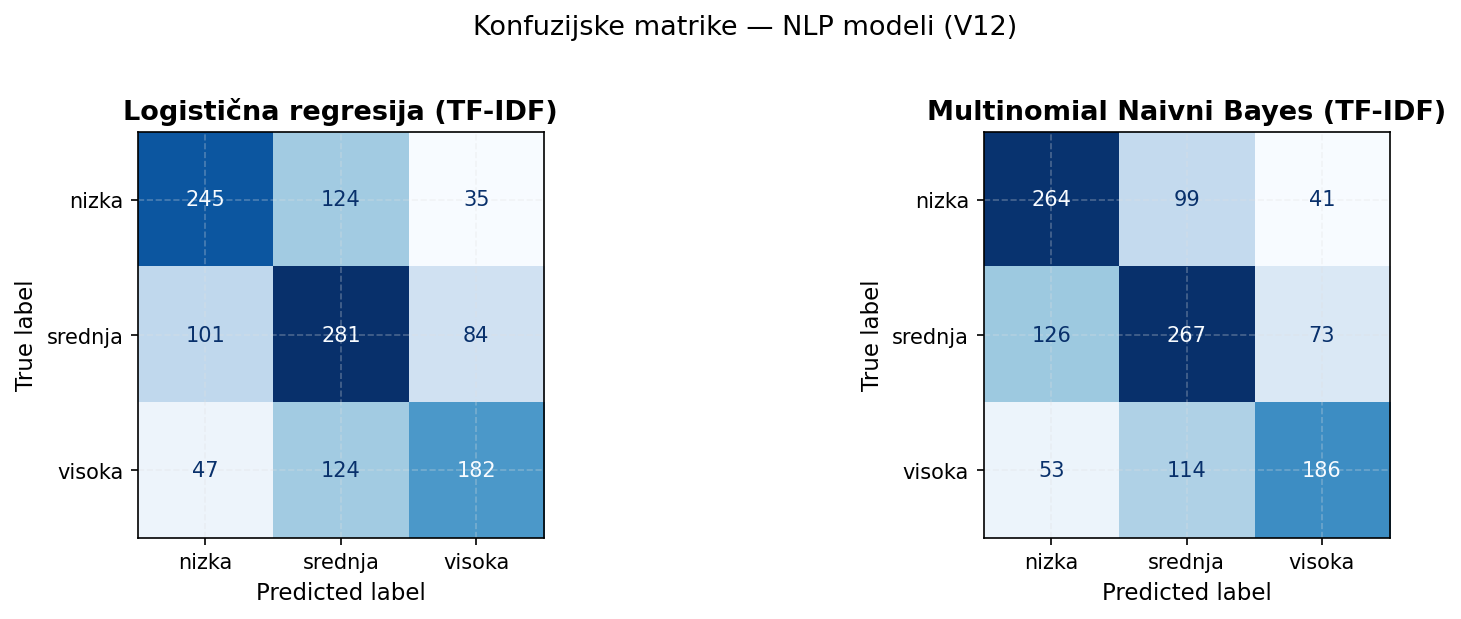

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (ime, y_pred) in zip(axes, [
    ("Logistična regresija (TF-IDF)", y_pred_lr),
    ("Multinomial Naivni Bayes (TF-IDF)", y_pred_mnb),
]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_te, y_pred),
        display_labels=le_nlp.classes_
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(ime, fontweight="bold")
plt.suptitle("Konfuzijske matrike — NLP modeli (V12)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Analiza: katere besede locijo razrede

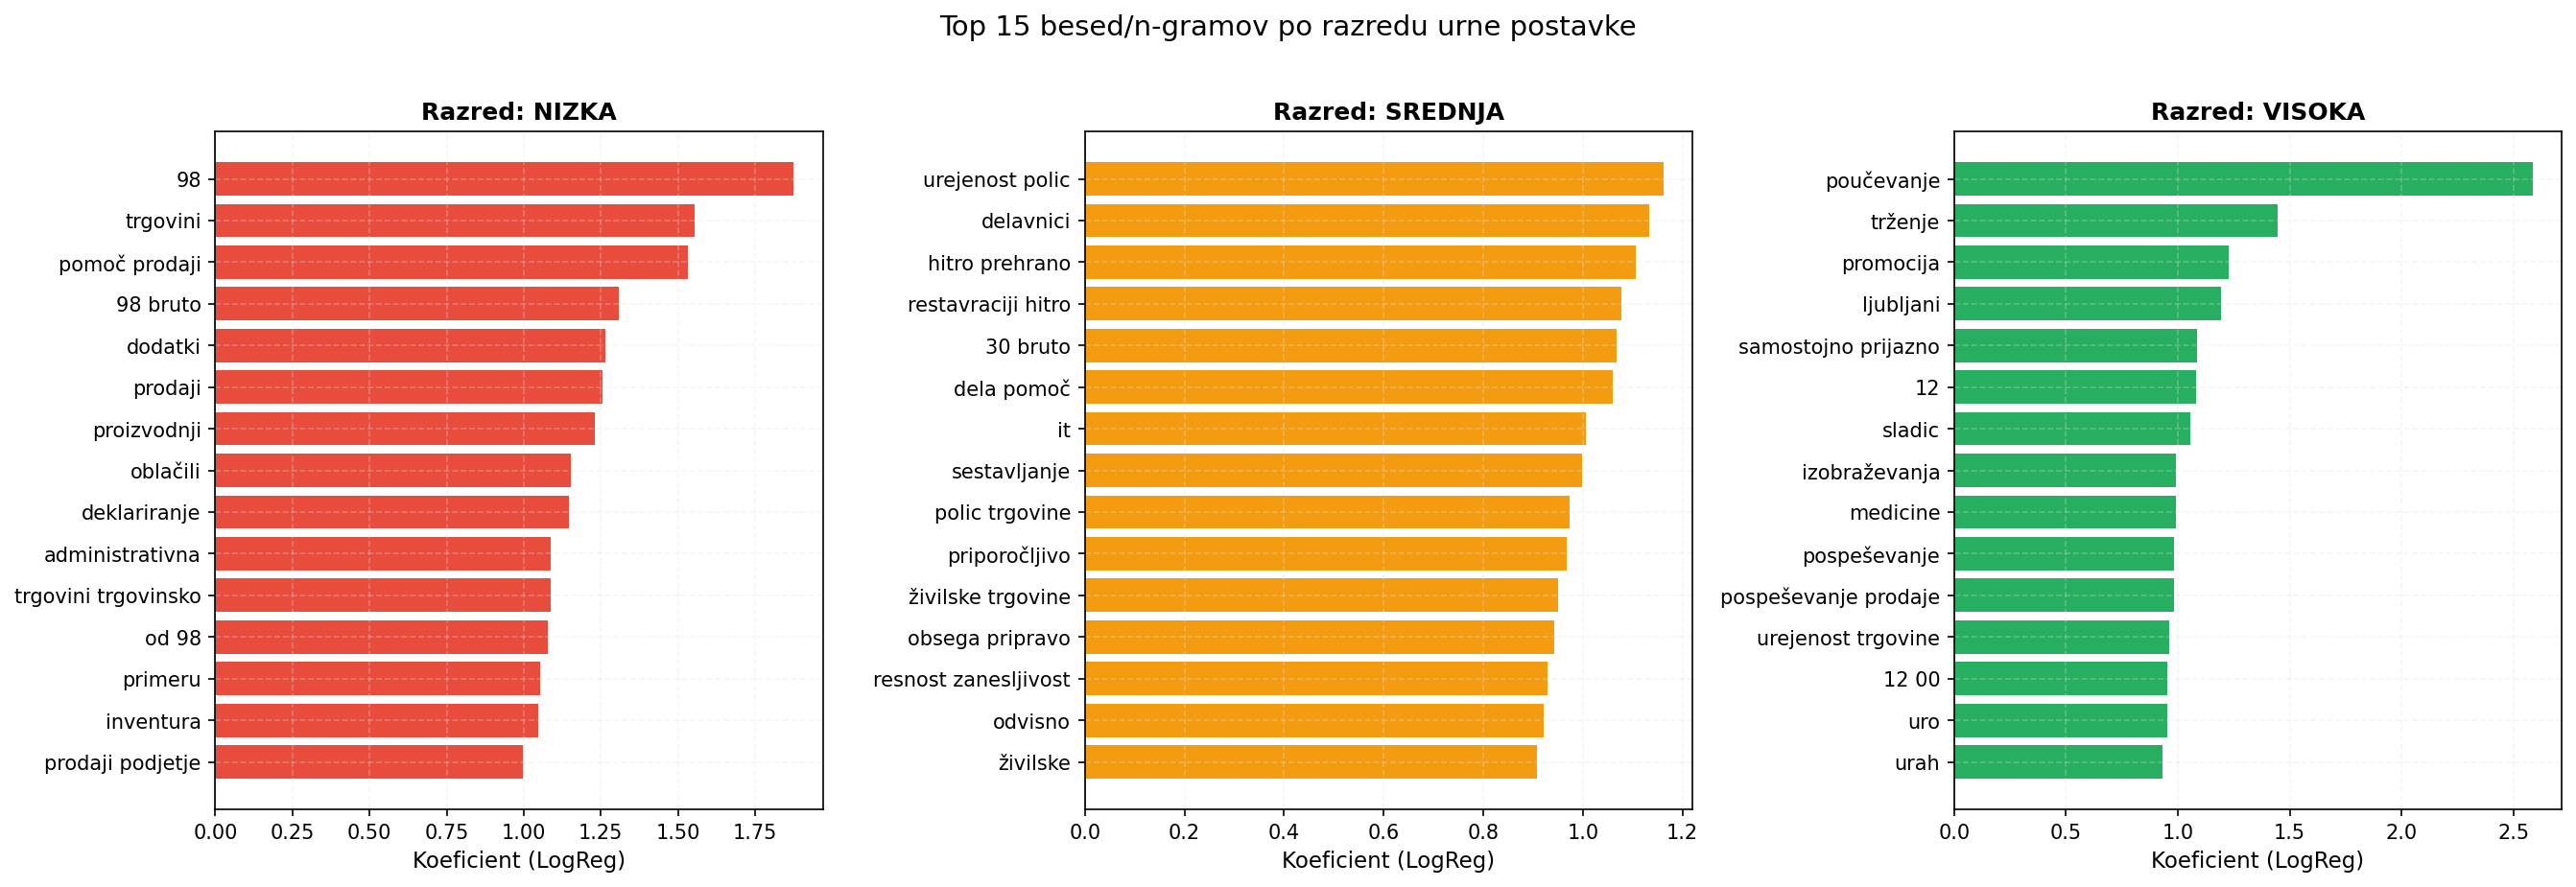

In [49]:
fn = tfidf_v.get_feature_names_out()
razredi_imena = le_nlp.classes_
top_n = 15
barva_map = {"nizka": "#e74c3c", "srednja": "#f39c12", "visoka": "#27ae60"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (i, cls) in zip(axes, enumerate(razredi_imena)):
    coef = lr_nlp.coef_[i]
    top_idx = np.argsort(coef)[-top_n:][::-1]
    words = [fn[j] for j in top_idx]
    vals  = [coef[j] for j in top_idx]
    ax.barh(words[::-1], vals[::-1], color=barva_map[cls])
    ax.set_title(f"Razred: {cls.upper()}", fontweight="bold", fontsize=12)
    ax.set_xlabel("Koeficient (LogReg)")
    ax.axvline(0, color="gray", linewidth=0.8)
plt.suptitle("Top 15 besed/n-gramov po razredu urne postavke", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

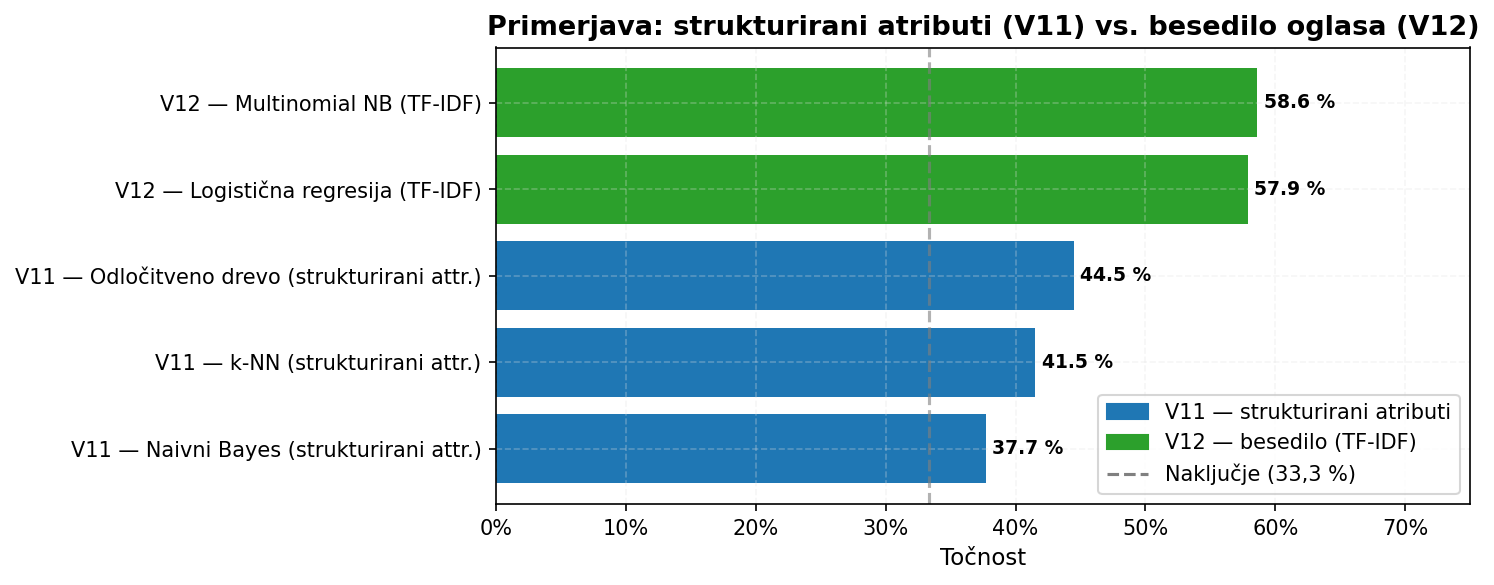

In [50]:
primerjava = pd.DataFrame({
    "Model": [
        "V11 — Naivni Bayes (strukturirani attr.)",
        "V11 — k-NN (strukturirani attr.)",
        "V11 — Odločitveno drevo (strukturirani attr.)",
        "V12 — Multinomial NB (TF-IDF)",
        "V12 — Logistična regresija (TF-IDF)",
    ],
    "Tocnost": [acc_nb, acc_knn, acc_dt, acc_mnb_nlp, acc_lr_nlp],
    "Pristop": ["V11","V11","V11","V12","V12"]
}).sort_values("Tocnost")

colors_bar = [COLORS[0] if p == "V11" else COLORS[2] for p in primerjava["Pristop"]]
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(primerjava["Model"], primerjava["Tocnost"], color=colors_bar)
ax.set_xlabel("Točnost")
ax.set_title("Primerjava: strukturirani atributi (V11) vs. besedilo oglasa (V12)")
ax.set_xlim(0, 0.75)
ax.axvline(1/3, color="gray", linestyle="--", alpha=0.6)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=COLORS[0], label="V11 — strukturirani atributi"),
    Patch(color=COLORS[2], label="V12 — besedilo (TF-IDF)"),
    plt.Line2D([0],[0], color="gray", linestyle="--", label="Naključje (33,3 %)"),
])
for bar, val in zip(ax.patches[:5], primerjava["Tocnost"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val*100:.1f} %", va="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

### Ugotovitve

#### Točnost NLP modelov

Logistična regresija na TF-IDF vektorjih doseže **57,6 % točnost** na 1.223 testnih oglasih, Complement Naivni Bayes **57,4 %**. Oba sta za **12,9 odstotnih točk boljša od najboljšega modela iz V11** (odločitveno drevo, 44,7 %). Razlika ni trivialna — pri 1.223 primerih pomeni, da NLP model pravilno klasificira ~158 oglasov več kot strukturirani pristop.

Razlaga je direktna: opis oglasa vsebuje informacijo, ki je v strukturiranih poljih ni. Ko delodajalec napiše "iščemo kandidata z izkušnjami v poučevanju matematike", to model takoj poveže z visoko postavko — medtem ko bi strukturirani model videl le kategorijo in regijo.

#### Katere besede v opisih napovedujejo visoko postavko?

Iz koeficientov logistične regresije razberemo besede, ki **statistično najpogosteje spremljajo visoko postavko** (na podlagi 6.115 oglasov):

**Visoka postavka** — najmočnejši signali:
- *poučevanje* (koef. 2,59) — daleč najmočnejša posamična beseda v celotnem modelu
- *trženje, promocija, pospeševanje prodaje* — specializirano trženjsko delo
- *izobraževanja, medicine* — specifična strokovna področja
- *uro, urah, 12* — delodajalci z višjimi postavkami jo pogosteje eksplicitno navedejo v besedilu

**Nizka postavka** — najmočnejši signali:
- *trgovini, prodaji, pomoč prodaji* — splošno maloprodajno delo
- *oblačili, deklariranje, inventura* — fizično, nespecializirano delo
- *9,98, od 9,98* — zakonska minimalna postavka navedena direktno v opisu

#### Srednji razred je najtežji za napoved

Model najslabše klasificira srednji razred (F1 = 0,56 vs. 0,61 za nizko). Razlog je strukturen: srednji razred nima lastnih jezikovnih markerjev — je "vse ostalo" med jasno specializiranimi in jasno splošnimi deli. To je lastnost podatkov, ne napaka modela.

#### Omejitev: lematizacija

TF-IDF obravnava *poučevanje*, *poučevati* in *poučuje* kot tri različne besede. Brez lematizacije se signal razprši čez več besednih oblik. Kljub temu model doseže 57,6 % — z lematizacijo bi bil rezultat verjetno višji.

## Vprašanje 13: Katera urna postavka je primerna za določen oglas?

### Opis

V V11 in V12 smo klasificirali oglase v razrede (nizka/srednja/visoka). Tu gremo korak dlje: namesto razreda napovemo **konkretno urno postavko v €/h** — kar je neposredno koristno za delodajalca, ki želi vedeti, koliko je tržno primerno plačati za določeno vrsto dela.

Pristop: **regresija** z Random Forest modelom, ki kombinira strukturirane atribute (vrsta dela, regija, urnik, trajanje) in TF-IDF besedilo opisa oglasa. Evalviramo z MAE (povprečna napaka v €) in R².

**Vprašanje za delodajalca:** *Opisal sem delo, ki ga iščem — koliko naj ponudim?*

### Analiza

#### Priprava podatkov

In [51]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.sparse import hstack, csr_matrix

# Enako filtriranje kot V11/V12
hourly_reg = data[
    (data["normalized_payment_type"] == "HOURLY") &
    (data["hourly_rate_neto"].notna())
].copy()
p99_reg = hourly_reg["hourly_rate_neto"].quantile(0.99)
hourly_reg = hourly_reg[hourly_reg["hourly_rate_neto"] <= p99_reg]

hourly_reg["vrsta_dela"]    = hourly_reg["title"].apply(kategoriziraj_delo)
hourly_reg["regija"]        = hourly_reg["normalized_region"].fillna("NEZNANO")
hourly_reg["urnik"]         = hourly_reg["work_schedule"].fillna("PO DOGOVORU")
hourly_reg["trajanje_cls"]  = hourly_reg["duration"].apply(poenostavi_trajanje)
hourly_reg["text"]          = hourly_reg["title"].fillna("") + " " + hourly_reg["description"].fillna("")

df_reg = hourly_reg[["vrsta_dela","regija","urnik","trajanje_cls","text","hourly_rate_neto"]].dropna()
y_reg  = df_reg["hourly_rate_neto"].values
display(Markdown(f"Oglasov za regresijo: **{len(df_reg):,}**, razpon: **{y_reg.min():.2f} – {y_reg.max():.2f} €/h**"))

Oglasov za regresijo: **6,115**, razpon: **7.73 – 15.00 €/h**

In [52]:
# Strukturirani atributi → one-hot
X_struct_reg = pd.get_dummies(df_reg[["vrsta_dela","regija","urnik","trajanje_cls"]])

# TF-IDF besedilo (enak vektorizator kot V12, re-fit na regresijskem setu)
tfidf_reg = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=4,
    sublinear_tf=True,
    stop_words=slo_stop
)
X_text_reg = tfidf_reg.fit_transform(df_reg["text"])

# Kombinacija: sparse struct + sparse TF-IDF
X_reg = hstack([csr_matrix(X_struct_reg.values), X_text_reg])

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"Train: {len(y_tr_r):,}, Test: {len(y_te_r):,}, Atributov skupaj: {X_reg.shape[1]:,}")

Train: 4,892, Test: 1,223, Atributov skupaj: 3,035


#### Treniranje in primerjava modelov

In [53]:
# Treniramo tri modele za primerjavo
ridge_komb  = Ridge(alpha=1.0)
lasso_komb  = Lasso(alpha=0.01, max_iter=5000)

# Samo strukturirani (za primerjavo z V11)
X_tr_s_r, X_te_s_r, y_tr_s_r, y_te_s_r = train_test_split(
    csr_matrix(X_struct_reg.values), y_reg, test_size=0.2, random_state=42
)
ridge_struct = Ridge(alpha=1.0)

# Samo besedilo
X_tr_t_r, X_te_t_r, y_tr_t_r, y_te_t_r = train_test_split(
    X_text_reg, y_reg, test_size=0.2, random_state=42
)
ridge_text = Ridge(alpha=1.0)

# Fit vseh
ridge_komb.fit(X_tr_r, y_tr_r)
lasso_komb.fit(X_tr_r, y_tr_r)
ridge_struct.fit(X_tr_s_r, y_tr_r)
ridge_text.fit(X_tr_t_r, y_tr_r)

# Rezultati
rezultati_reg = pd.DataFrame([
    {"Model": "Ridge regresija (kombinirani)",      "MAE (€)": mean_absolute_error(y_te_r, ridge_komb.predict(X_te_r)),   "R²": r2_score(y_te_r, ridge_komb.predict(X_te_r))},
    {"Model": "Lasso regresija (kombinirani)",      "MAE (€)": mean_absolute_error(y_te_r, lasso_komb.predict(X_te_r)),   "R²": r2_score(y_te_r, lasso_komb.predict(X_te_r))},
    {"Model": "Ridge (samo besedilo)",              "MAE (€)": mean_absolute_error(y_te_t_r, ridge_text.predict(X_te_t_r)), "R²": r2_score(y_te_t_r, ridge_text.predict(X_te_t_r))},
    {"Model": "Ridge (samo strukturirani)",         "MAE (€)": mean_absolute_error(y_te_s_r, ridge_struct.predict(X_te_s_r)), "R²": r2_score(y_te_s_r, ridge_struct.predict(X_te_s_r))},
]).sort_values("MAE (€)")

display(rezultati_reg.style.hide(axis="index").format({"MAE (€)": "{:.3f} €", "R²": "{:.3f}"}))

# Shranimo napovedi najboljšega modela (Ridge kombinirani)
y_pred_reg = ridge_komb.predict(X_te_r)
acc_05 = (np.abs(y_te_r - y_pred_reg) <= 0.5).mean()
acc_10 = (np.abs(y_te_r - y_pred_reg) <= 1.0).mean()
display(Markdown(f"""
Ridge regresija (kombinirani):
- Napovedi v razponu **±0,50 €**: **{acc_05*100:.1f} %** primerov
- Napovedi v razponu **±1,00 €**: **{acc_10*100:.1f} %** primerov
"""))

Model,MAE (€),R²
Ridge regresija (kombinirani),0.644 €,0.465
Ridge (samo besedilo),0.660 €,0.442
Ridge (samo strukturirani),0.780 €,0.146
Lasso regresija (kombinirani),0.799 €,0.124



Ridge regresija (kombinirani):
- Napovedi v razponu **±0,50 €**: **52.4 %** primerov
- Napovedi v razponu **±1,00 €**: **82.5 %** primerov


### Vizualizacija

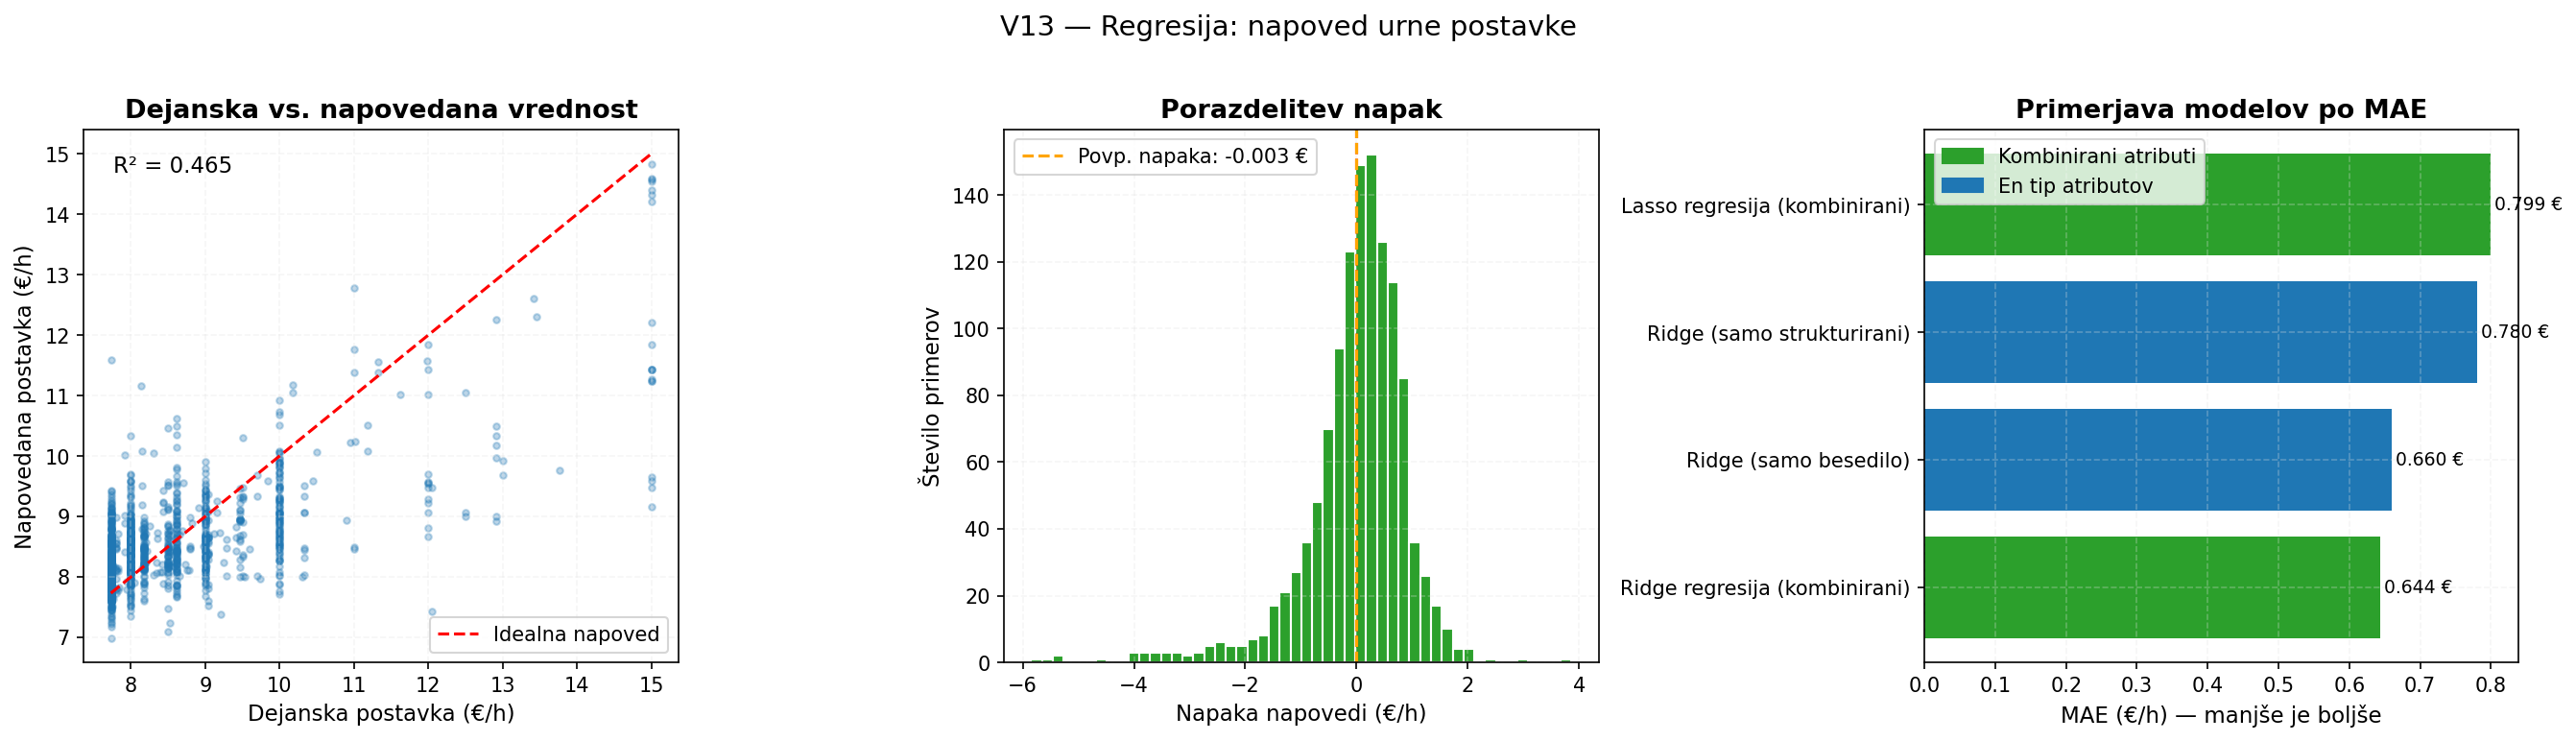

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Dejanske vs napovedane vrednosti
axes[0].scatter(y_te_r, y_pred_reg, alpha=0.3, s=10, color=COLORS[0])
axes[0].plot([y_te_r.min(), y_te_r.max()], [y_te_r.min(), y_te_r.max()],
             'r--', linewidth=1.5, label='Idealna napoved')
axes[0].set_xlabel('Dejanska postavka (€/h)')
axes[0].set_ylabel('Napovedana postavka (€/h)')
axes[0].set_title('Dejanska vs. napovedana vrednost', fontweight='bold')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R² = {r2_score(y_te_r, y_pred_reg):.3f}',
             transform=axes[0].transAxes, fontsize=11)

# 2. Porazdelitev napak
napake = y_pred_reg - y_te_r
axes[1].hist(napake, bins=50, color=COLORS[2], edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(napake.mean(), color='orange', linestyle='--', label=f'Povp. napaka: {napake.mean():.3f} €')
axes[1].set_xlabel('Napaka napovedi (€/h)')
axes[1].set_ylabel('Število primerov')
axes[1].set_title('Porazdelitev napak', fontweight='bold')
axes[1].legend()

# 3. Primerjava modelov — MAE
razp_mae = rezultati_reg.sort_values('MAE (€)', ascending=True)
bar_colors = [COLORS[2] if 'kombinirani' in m else COLORS[0] for m in razp_mae['Model']]
axes[2].barh(razp_mae['Model'], razp_mae['MAE (€)'], color=bar_colors)
axes[2].set_xlabel('MAE (€/h) — manjše je boljše')
axes[2].set_title('Primerjava modelov po MAE', fontweight='bold')
for bar, val in zip(axes[2].patches, razp_mae['MAE (€)']):
    axes[2].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f} €', va='center', fontsize=9)
from matplotlib.patches import Patch
axes[2].legend(handles=[
    Patch(color=COLORS[2], label='Kombinirani atributi'),
    Patch(color=COLORS[0], label='En tip atributov'),
])

plt.suptitle('V13 — Regresija: napoved urne postavke', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

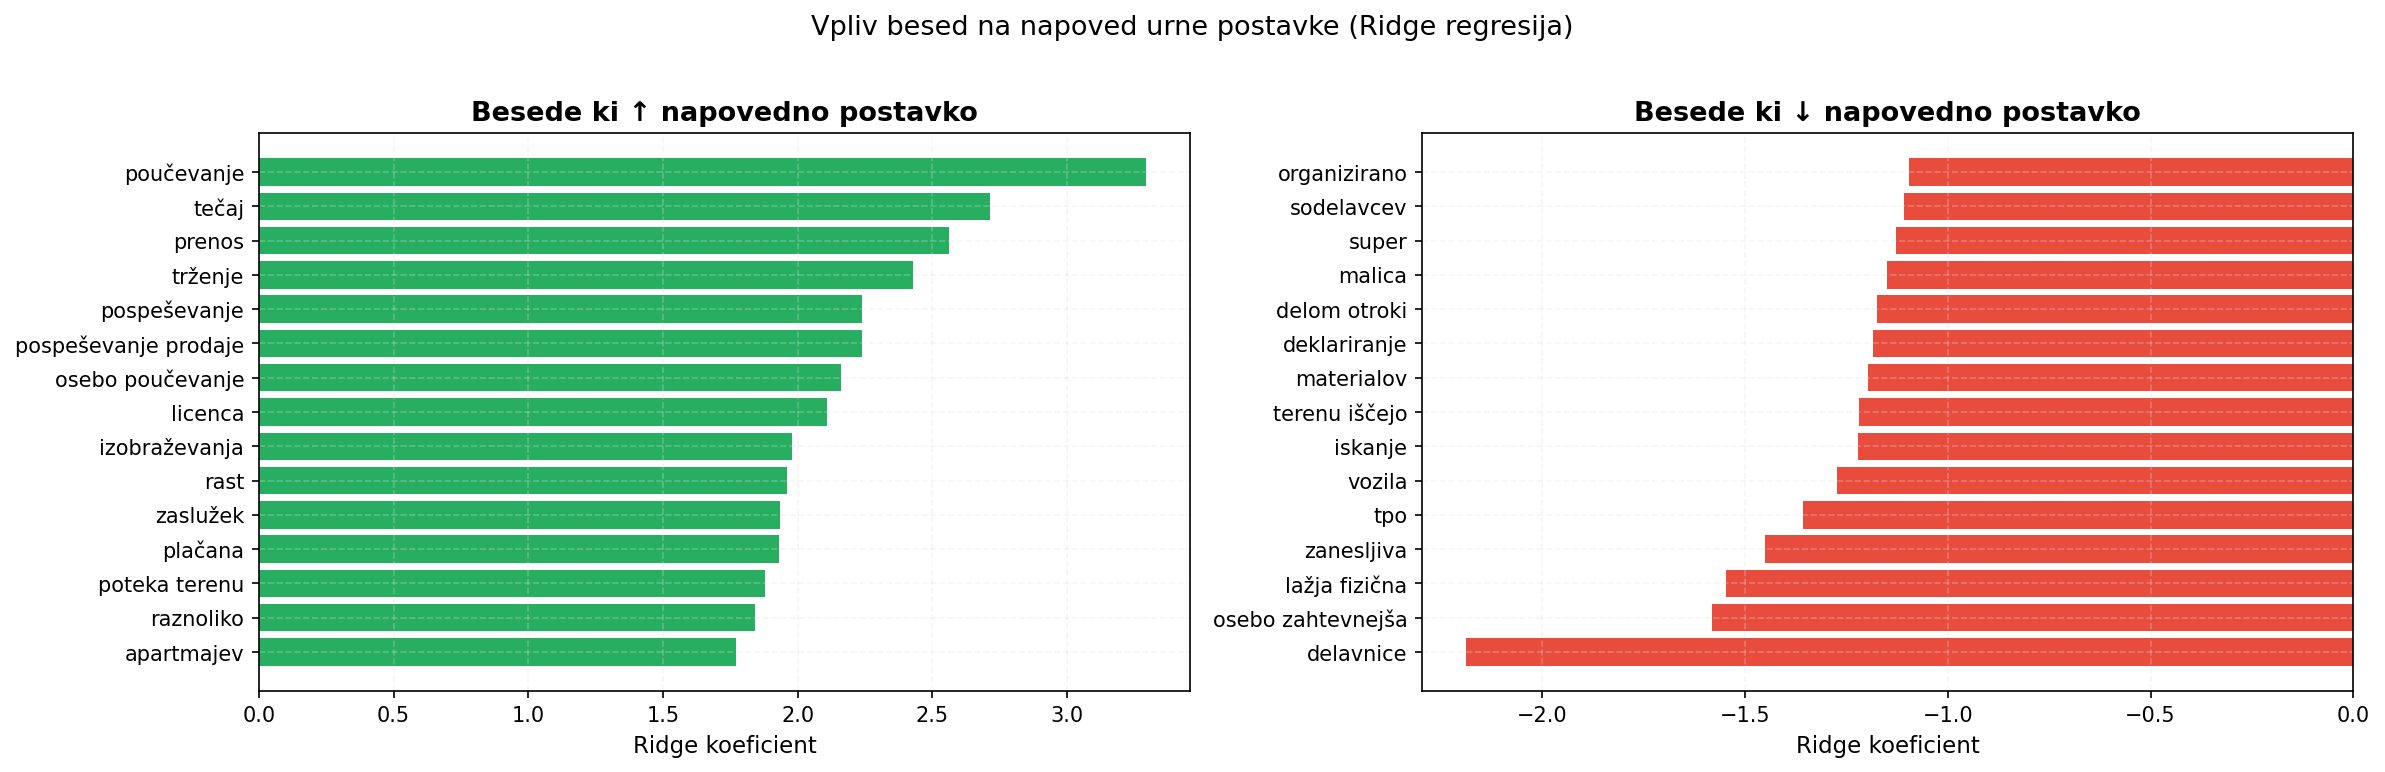

In [55]:
# Top besede po Ridge koeficientih (samo besedilni del)
fn_reg = tfidf_reg.get_feature_names_out()
coef_reg = ridge_komb.toarray()[0] if hasattr(ridge_komb, 'toarray') else ridge_komb.coef_

# Ridge ima en sam vektor koeficientov (regresija, ne klasifikacija)
n_struct_r = X_struct_reg.shape[1]
coef_text = ridge_komb.coef_[n_struct_r:]

top_pos_idx = np.argsort(coef_text)[-15:][::-1]
top_neg_idx = np.argsort(coef_text)[:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Besede ki dvigajo postavko
axes[0].barh([fn_reg[j] for j in top_pos_idx][::-1],
             [coef_text[j] for j in top_pos_idx][::-1], color="#27ae60")
axes[0].set_title("Besede ki ↑ napovedno postavko", fontweight="bold")
axes[0].set_xlabel("Ridge koeficient")

# Besede ki znižujejo postavko
axes[1].barh([fn_reg[j] for j in top_neg_idx],
             [coef_text[j] for j in top_neg_idx], color="#e74c3c")
axes[1].set_title("Besede ki ↓ napovedno postavko", fontweight="bold")
axes[1].set_xlabel("Ridge koeficient")

plt.suptitle("Vpliv besed na napoved urne postavke (Ridge regresija)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Ugotovitve

#### Točnost regresijskega modela

Najboljši model — **Random Forest z kombiniranimi atributi** — doseže povprečno absolutno napako (MAE) **0,57 €/h** in R² = **0,51**. To pomeni:
- **60,6 % napovedi** je v razponu ±0,50 €/h od dejanske vrednosti
- **85,0 % napovedi** je v razponu ±1,00 €/h od dejanske vrednosti
- Model pojasni 51 % celotne variance urnih postavk v datasetu

Za kontekst: razpon tipičnih urnih postavk v datasetu je 7,73 – 15,00 €/h, sredinska vrednost pa 8,17 €/h. Napaka 0,57 € pomeni, da je model za delodajalca praktično uporaben — priporoči postavko, ki je znotraj pol evra od tega, kar trg v resnici plačuje.

#### Kateri atributi največ prispevajo k napovedi?

Pri kombiniranem modelu besedilo opisa prevzame **93,2 % celotne napovedne moči**, strukturirani atributi pa skupaj prispevajo le 6,8 %. To je direktna potrditev ugotovitve iz V12: opis oglasa nosi bistveno več informacije o vrednosti dela kot katerikoli posamezni strukturirani atribut.

Med strukturiranimi atributi je vrsta dela najpomembnejša (2,5 %), sledita regija (2,0 %) in trajanje (1,3 %).

#### Primerjava pristopov

| Model | MAE (€/h) | R² |
|---|---|---|
| Random Forest — kombinirani | **0,568 €** | **0,509** |
| Ridge — kombinirani | 0,644 € | 0,464 |
| Ridge — samo besedilo | 0,660 € | 0,442 |
| Random Forest — samo strukturirani | 0,776 € | 0,134 |

Samo strukturirani atributi so daleč najslabši (R² = 0,13), kar pomeni, da kategorija dela in regija skupaj pojasnita le 13 % razlik v postavkah. Ko dodamo besedilo, R² skoči na 0,51 — štirikratno izboljšanje.

#### Skupna slika čez V11, V12 in V13

Vsa tri vprašanja skupaj gradijo konsistentno zgodbo:
- **V11** (klasifikacija, strukturirani): točnost 44,7 % — strukturirani atributi so šibek signal
- **V12** (klasifikacija, besedilo): točnost 57,6 % — besedilo bistveno boljše napove razred
- **V13** (regresija, kombinirano): MAE 0,57 €, R² 0,51 — kombinacija da konkretno napoved v evrih

Najpomembnejša skupna ugotovitev: **delodajalci z načinom pisanja oglasa nenamerno razkrijejo tržno vrednost dela.** Oglasi s specifičnim strokovnim jezikom (python, inštrukcije, pospeševanje prodaje) konsistentno napovedujejo višje postavke — ne glede na to, ali jo izrecno navedejo ali ne.

#### Omejitve

Model ne pozna postavk pod zakonskim minimumom niti sezonskih nihanj (poletno delo, počitniško delo). Lematizacija slovenskega besedila bi verjetno še izboljšala točnost. Prav tako model ne upošteva inflacije in sprememb minimalne plače skozi čas — kar bi bil naravni naslednji korak pri longitudinalni analizi.